# L1 vs. Stochastic Gates: How Simulation Settings Affect Gene-Finding

**The question this notebook answers:** when the genes that actually matter for a
disease are correlated with each other (they move up and down together, the way
genes in the same biological pathway do), do standard gene-selection methods still
find all of them — or do they only grab one or two and miss the rest?

Two methods are compared throughout:
- **L1 (LASSO)** — a classic, widely-used method. It tries to predict disease status
  using as few genes as possible, and sets every gene it doesn't need to exactly zero.
- **Stochastic Gates (STG)** — give every gene its own learnable on/off switch,
  trained together with the prediction model, using the official `stg` package from
  the method's original authors.

**What this notebook does, in order:**
1. Explain how the fake (simulated) data is built, in plain terms.
2. Get both methods ready — confirm they work, and lock in every setting so the
   comparison stays fair across everything that follows.
3. Run four separate experiments, each one turning a single simulation "dial" through
   five settings while holding everything else fixed, to see which dial(s) actually
   break gene-finding and by how much.

**This particular notebook** covers Section 1 (this cell) through the end of
**Experiment 1 (correlation strength)** — the other three experiments (signal
strength, measurement noise, patient-to-patient variability) are built next, once
this section is confirmed to look right.

## Section 2: How the fake data is built (plain-language version)

No equations here — just the intuition needed to read everything below.

- **Two groups of patients:** disease patients and control patients (10 of each).
  Each patient contributes many individual cell measurements (50 cells per patient),
  since this mimics single-cell data, not one measurement per patient.
- **1,000 genes are measured per cell. Only 100 of them actually matter** for
  telling disease from control ("signal genes"); the other 900 are pure noise
  ("background genes") — they're simulated with no real difference between the two
  groups at all.
- **All 100 real genes are treated as one single group ("module")** that is
  deliberately made to move together — the whole point of this project is testing
  whether standard methods can find a *whole group* of correlated genes, not just
  one representative gene from it.
- **Four dials control how hard or easy the problem is**, and this notebook turns
  each one individually, one at a time, while leaving the other three fixed:
  1. **Correlation strength** — how strongly the 100 real genes move together.
     Weak correlation looks a lot like 100 independent genes; strong correlation
     means they behave almost as a single block.
  2. **Signal strength (fold change)** — how much higher the real genes' average
     expression is in disease patients vs. controls.
  3. **Measurement noise (dispersion)** — how noisy an individual gene's reading is,
     separate from any real biological difference.
  4. **Patient-to-patient variability** — how much patients naturally differ from
     each other, regardless of disease status (some patients just run "hotter" or
     "cooler" across every gene).

Every dataset used below comes from `data_generators.py` (already in this folder,
and already fixed to match the project's validated math) — nothing about the
simulator itself is reimplemented here, only called with different dial settings.

## Setup: imports and reproducibility

Standard imports, a fixed random seed, and the same Python 3.10+ compatibility fix
the `stg` package needs elsewhere in this repo (see `CLAUDE.md`).

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  # avoid oversubscription during STG's torch training loop

import random
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)  # sklearn 1.8+ penalty= deprecation noise
warnings.filterwarnings("ignore", message="Implicit dimension choice for softmax")  # cosmetic noise from the stg package

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import nbinom, norm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
)

# --- Python 3.10+ compatibility shim for the `stg` package ---
import collections, collections.abc
for _name in ("Iterable", "Mapping", "Sequence", "Set", "MutableMapping",
              "MutableSequence", "MutableSet", "Callable", "Hashable",
              "Sized", "Container"):
    if not hasattr(collections, _name):
        setattr(collections, _name, getattr(collections.abc, _name))

from stg import STG
from stg.utils import as_tensor, as_numpy, SimpleDataset
from torch.utils.data import DataLoader

from data_generators import generate_flat_data, generate_correlated_data

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")
METHOD_COLORS = {"L1": "#1f77b4", "STG": "#d62728"}

print("Imports OK.")

Imports OK.


## Setup: the project's standard settings

These are the same default numbers used everywhere else in this project. Every
experiment below holds all four dials at these defaults **except** the one dial
being tested, which moves through its own list of test values instead.

In [2]:
DEFAULTS = dict(
    n_patients_group1=10,
    n_patients_group2=10,
    cells_per_patient=50,
    n_genes_total=1000,
    n_signal_genes=100,
    fold_change=3,              # dial 2 default (Experiment 2 tests 2, 4, 6, 8, 10)
    mu_background=2,
    sigma2=0.20,                 # dial 4 default (Experiment 4 tests 0.05, 0.10, 0.20, 0.40, 0.80)
    dispersion=15.0,             # dial 3 default (Experiment 3 tests 5, 10, 15, 25, 40)
    size_factor_mean=2000,
    size_factor_sd=300,
)

CORRELATED_ONLY_DEFAULTS = dict(
    n_modules=1,                 # one single gene module, as requested -- not the 4-module setup used elsewhere
    n_distractor_modules=0,
    within_module_correlation=0.6,  # dial 1 default (Experiment 1 tests none, 0.2, 0.4, 0.6, 0.8)
    correlation_noise=0.0,
)

SEEDS = [42, 43]  # 2 independent redraws per setting, averaged

print("Standard settings:")
for k, v in {**DEFAULTS, **CORRELATED_ONLY_DEFAULTS}.items():
    print(f"  {k} = {v}")

Standard settings:
  n_patients_group1 = 10
  n_patients_group2 = 10
  cells_per_patient = 50
  n_genes_total = 1000
  n_signal_genes = 100
  fold_change = 3
  mu_background = 2
  sigma2 = 0.2
  dispersion = 15.0
  size_factor_mean = 2000
  size_factor_sd = 300
  n_modules = 1
  n_distractor_modules = 0
  within_module_correlation = 0.6
  correlation_noise = 0.0


## Setup: reusable steps (defined once, reused for every setting)

Every one of the 20+ dataset settings tested below needs the exact same sequence of
steps: generate the data, split patients into train/test, clean up the numbers, fit
both methods, and measure how well each one did. Rather than repeating that
sequence by hand 20+ times, it's written once here as a small set of named steps
and simply reused everywhere below. Nothing about the underlying method changes —
this is purely about not repeating the same block of code over and over.

In [3]:
def generate_condition(kind, **overrides):
    """kind = "flat" or "correlated". overrides replaces specific DEFAULTS/
    CORRELATED_ONLY_DEFAULTS entries (e.g. within_module_correlation=0.2)."""
    if kind == "flat":
        params = {**DEFAULTS, **overrides}
        return generate_flat_data(**params)
    else:
        params = {**DEFAULTS, **CORRELATED_ONLY_DEFAULTS, **overrides}
        return generate_correlated_data(**params)


def patient_level_split(patients_df, cells_df, X_index, base_seed,
                         test_size=0.2, min_patients_per_group=2, max_tries=200):
    """Patient-level GroupShuffleSplit, retried until both groups have
    >= min_patients_per_group patients on both the train and test side
    (keeps AUROC well-defined -- see l1_vs_stg_baseline_comparison.ipynb for the
    empirical case that motivated this retry loop)."""
    patient_id_per_cell = cells_df.set_index("cell_id").loc[X_index, "patient_id"].values
    n_cells = len(X_index)

    for attempt in range(max_tries):
        rs = base_seed * 1000 + attempt
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=rs)
        train_idx, test_idx = next(gss.split(np.zeros(n_cells), groups=patient_id_per_cell))

        train_patients = set(patient_id_per_cell[train_idx])
        test_patients = set(patient_id_per_cell[test_idx])
        train_counts = patients_df[patients_df.patient_id.isin(train_patients)]["group"].value_counts()
        test_counts = patients_df[patients_df.patient_id.isin(test_patients)]["group"].value_counts()

        if (test_counts.get("Group1", 0) >= min_patients_per_group and
                test_counts.get("Group2", 0) >= min_patients_per_group and
                train_counts.get("Group1", 0) >= min_patients_per_group and
                train_counts.get("Group2", 0) >= min_patients_per_group):
            return train_idx, test_idx

    raise RuntimeError(f"No balanced patient-level split found in {max_tries} tries (base_seed={base_seed})")


def preprocess(data, seed):
    """Size-factor normalize, log1p, then z-score (train-fit only)."""
    X, y, cells_df, patients_df = data["X"], data["y"], data["cells_df"], data["patients_df"]
    train_idx, test_idx = patient_level_split(patients_df, cells_df, X.index, base_seed=seed)

    size_factor = cells_df.set_index("cell_id").loc[X.index, "size_factor"].values
    X_norm = np.log1p(X.values / size_factor[:, None])

    X_train_raw, X_test_raw = X_norm[train_idx], X_norm[test_idx]
    y_train, y_test = y.values[train_idx], y.values[test_idx]

    scaler = StandardScaler().fit(X_train_raw)
    return {
        "X_train": scaler.transform(X_train_raw), "X_test": scaler.transform(X_test_raw),
        "y_train": y_train, "y_test": y_test, "gene_ids": X.columns.values,
        "train_idx": train_idx, "test_idx": test_idx,
    }


def fit_l1(pre, seed):
    l1 = LogisticRegressionCV(
        Cs=5, cv=3, penalty="l1", solver="saga",
        max_iter=2000, tol=1e-3, n_jobs=-1, random_state=seed,
    )
    l1.fit(pre["X_train"], pre["y_train"])
    coef = l1.coef_[0]
    y_proba = l1.predict_proba(pre["X_test"])[:, 1]
    return {
        "selected": coef != 0,
        "importance": np.abs(coef),
        "accuracy": accuracy_score(pre["y_test"], (y_proba > 0.5).astype(int)),
        "auroc": roc_auc_score(pre["y_test"], y_proba),
    }


def stg_predict_proba(model, X):
    """STG.predict() only returns the hard class label -- this mirrors the same
    forward pass but returns the softmax probability of class 1, for AUROC."""
    dataset = SimpleDataset(X)
    loader = DataLoader(dataset, batch_size=X.shape[0], shuffle=False)
    model._model.eval()
    probs = []
    for feed_dict in loader:
        feed_dict = as_tensor(feed_dict)
        with torch.no_grad():
            output_dict = model._model(feed_dict)
        probs.append(as_numpy(output_dict["prob"]))
    return np.concatenate(probs, axis=0)[:, 1]


def fit_stg(pre, lam, seed, nr_epochs=200):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = STG(
        task_type="classification", input_dim=pre["X_train"].shape[1], output_dim=2,
        hidden_dims=[128, 32], activation="tanh", optimizer="Adam", learning_rate=0.01,
        batch_size=pre["X_train"].shape[0], feature_selection=True, sigma=0.5, lam=lam,
        random_state=seed, device="cpu",
    )
    model.fit(pre["X_train"], pre["y_train"].astype(float), nr_epochs=nr_epochs, verbose=False)
    gate_probs = model.get_gates(mode="prob")
    proba = stg_predict_proba(model, pre["X_test"])
    return {
        "selected": gate_probs > 0.5,
        "importance": gate_probs,
        "accuracy": accuracy_score(pre["y_test"], (proba > 0.5).astype(int)),
        "auroc": roc_auc_score(pre["y_test"], proba),
    }


def score_selection(result, gene_ids, true_signal_mask):
    selected = result["selected"]
    n_true_signal = int(true_signal_mask.sum())
    n_true_background = int((~true_signal_mask).sum())
    n_signal_recovered = int((selected & true_signal_mask).sum())
    n_background_leaked = int((selected & ~true_signal_mask).sum())
    return {
        **{k: result[k] for k in ("accuracy", "auroc")},
        "n_selected": int(selected.sum()),
        "precision": precision_score(true_signal_mask, selected, zero_division=0),
        "recall": recall_score(true_signal_mask, selected, zero_division=0),
        "f1": f1_score(true_signal_mask, selected, zero_division=0),
        # signal vs. background breakdown of what got selected
        "n_signal_recovered": n_signal_recovered,
        "n_background_leaked": n_background_leaked,
        "pct_signal_recovered": 100.0 * n_signal_recovered / n_true_signal,
        "pct_background_leaked": 100.0 * n_background_leaked / n_true_background,
    }

print("Core fit/score steps defined.")

Core fit/score steps defined.


In [4]:
def run_condition(kind, lam, seeds=SEEDS, **overrides):
    """Runs Section 2's full pipeline once per seed for one dial setting, then
    averages the L1 and STG results across seeds. Also keeps the FIRST seed's
    full generated dataset around, for the "what does this data look like" plots."""
    per_seed_rows = []
    example = None

    for seed in seeds:
        data = generate_condition(kind, seed=seed, **overrides)
        gene_ids_all = data["X"].columns.values
        true_signal_mask = data["genes_df"].set_index("gene_id").loc[gene_ids_all, "gene_type"].values == "signal"

        pre = preprocess(data, seed=seed)
        l1_result = fit_l1(pre, seed=seed)
        stg_result = fit_stg(pre, lam=lam, seed=seed)

        per_seed_rows.append({
            "seed": seed,
            "L1": score_selection(l1_result, gene_ids_all, true_signal_mask),
            "STG": score_selection(stg_result, gene_ids_all, true_signal_mask),
        })

        if example is None:
            example = {"data": data, "l1_result": l1_result, "stg_result": stg_result,
                       "gene_ids_all": gene_ids_all, "true_signal_mask": true_signal_mask}

    averaged = {}
    for method in ("L1", "STG"):
        keys = per_seed_rows[0][method].keys()
        averaged[method] = {k: float(np.mean([row[method][k] for row in per_seed_rows])) for k in keys}

    return {"kind": kind, "overrides": overrides, "averaged": averaged,
            "per_seed": per_seed_rows, "example": example}

print("run_condition() defined -- this is the one function called for every setting below.")

run_condition() defined -- this is the one function called for every setting below.


## Setup: reusable pictures (defined once, reused for every setting)

Two small picture-drawing steps, used identically for every setting below:
1. **"What does this data look like?"** — two quick pictures of one example dataset
   from a given setting: how correlated the real genes actually are with each other,
   and whether disease patients visibly show higher expression of those genes.
2. **"How did L1 and STG do, just for this one setting?"** — a single side-by-side
   comparison picture, never combined with any other setting's numbers.

In [5]:
def get_module_gene_ids(data):
    """The 100 real ('signal') genes, regardless of whether this came from the
    flat generator (no module_id column) or the correlated generator (module_id)."""
    genes_df = data["genes_df"]
    return genes_df.loc[genes_df["gene_type"] == "signal", "gene_id"].tolist()


def plot_data_overview(result, title):
    data = result["example"]["data"]
    module_genes = get_module_gene_ids(data)
    cells_df = data["cells_df"]

    # counts_df already carries cell_id/size_factor/group (baked in at generation time),
    # no need to re-merge cells_df
    counts_df = data["counts_df"].copy()
    counts_df["norm_expression"] = counts_df["expression"] / counts_df["size_factor"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Panel 1: correlation heatmap, real genes (subsampled to 25) vs. an equal-sized
    # sample of background genes, measured on Group1 (disease) cells only.
    rng_local = np.random.default_rng(0)
    heatmap_genes = list(rng_local.choice(module_genes, min(25, len(module_genes)), replace=False))
    background_genes = data["genes_df"].loc[data["genes_df"]["gene_type"] == "background", "gene_id"].tolist()
    heatmap_genes += list(rng_local.choice(background_genes, 15, replace=False))

    g1_cells = cells_df.loc[cells_df["group"] == "Group1", "cell_id"]
    mat = counts_df[counts_df["cell_id"].isin(g1_cells) & counts_df["gene_id"].isin(heatmap_genes)].pivot_table(
        index="gene_id", columns="cell_id", values="norm_expression"
    ).loc[heatmap_genes]
    sns.heatmap(mat.T.corr(), ax=axes[0], cmap="RdBu_r", vmin=-1, vmax=1,
                xticklabels=False, yticklabels=False, cbar_kws={"label": "correlation"})
    axes[0].axvline(25, color="black", linewidth=1.5)
    axes[0].axhline(25, color="black", linewidth=1.5)
    axes[0].set_title("Gene-gene correlation\n(first 25 = real genes, last 15 = background)")

    # Panel 2: per-cell average expression across the real genes, disease vs. control.
    module_mean = counts_df[counts_df["gene_id"].isin(module_genes)].groupby(
        ["cell_id", "group"]
    )["norm_expression"].mean().reset_index()
    sns.boxplot(data=module_mean, x="group", y="norm_expression", hue="group", ax=axes[1],
                palette={"Group1": "#d62728", "Group2": "#1f77b4"}, legend=False)
    axes[1].set_title("Real-gene expression by group\n(disease vs. control)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Average normalized expression")

    fig.suptitle(title, y=1.04, fontsize=16)
    plt.tight_layout()
    plt.show()


def _bar_with_labels(ax, values, labels, colors, value_fmt="{:.0f}"):
    bars = ax.bar(labels, values, color=colors)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                value_fmt.format(val), ha="center", va="bottom", fontsize=11)
    return bars


def plot_method_comparison(result, title):
    avg = result["averaged"]
    n_true_signal = DEFAULTS["n_signal_genes"]
    n_true_background = DEFAULTS["n_genes_total"] - n_true_signal
    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

    # Panel 1: accuracy / AUROC / gene-recovery F1
    metrics = ["accuracy", "auroc", "f1"]
    metric_labels = ["Accuracy", "AUROC", "Gene-recovery F1"]
    x = np.arange(len(metrics))
    width = 0.35
    for i, method in enumerate(["L1", "STG"]):
        vals = [avg[method][m] for m in metrics]
        axes[0].bar(x + (i - 0.5) * width, vals, width, label=method, color=METHOD_COLORS[method])
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metric_labels)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title("Prediction quality &\ngene-finding quality")
    axes[0].legend()

    # Panel 2: total genes kept, vs. the correct answer
    n_sel = [avg["L1"]["n_selected"], avg["STG"]["n_selected"]]
    _bar_with_labels(axes[1], n_sel, ["L1", "STG"], [METHOD_COLORS["L1"], METHOD_COLORS["STG"]])
    axes[1].axhline(n_true_signal, linestyle="--", color="black", linewidth=2,
                     label=f"correct answer: {n_true_signal} real genes")
    axes[1].set_title("Total genes kept\n(real + background combined)")
    axes[1].set_ylabel("genes selected (out of 1000)")
    axes[1].legend()

    # Panel 3: how many of the 100 real genes were actually found (count + %)
    signal_counts = [avg["L1"]["n_signal_recovered"], avg["STG"]["n_signal_recovered"]]
    signal_pcts = [avg["L1"]["pct_signal_recovered"], avg["STG"]["pct_signal_recovered"]]
    signal_labels = [f"{c:.0f}\n({p:.0f}%)" for c, p in zip(signal_counts, signal_pcts)]
    bars3 = axes[2].bar(["L1", "STG"], signal_counts, color=[METHOD_COLORS["L1"], METHOD_COLORS["STG"]])
    for bar, lab in zip(bars3, signal_labels):
        axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), lab,
                     ha="center", va="bottom", fontsize=11)
    axes[2].axhline(n_true_signal, linestyle="--", color="black", linewidth=2,
                     label=f"target: all {n_true_signal} real genes")
    axes[2].set_ylim(0, n_true_signal * 1.15)
    axes[2].set_title("Real genes correctly found\n(out of 100 -- higher is better)")
    axes[2].set_ylabel("real genes found")
    axes[2].legend()

    # Panel 4: how many of the 900 background (noise) genes got kept by mistake (count + %)
    bg_counts = [avg["L1"]["n_background_leaked"], avg["STG"]["n_background_leaked"]]
    bg_pcts = [avg["L1"]["pct_background_leaked"], avg["STG"]["pct_background_leaked"]]
    bg_labels = [f"{c:.0f}\n({p:.1f}%)" for c, p in zip(bg_counts, bg_pcts)]
    bars4 = axes[3].bar(["L1", "STG"], bg_counts, color=[METHOD_COLORS["L1"], METHOD_COLORS["STG"]])
    for bar, lab in zip(bars4, bg_labels):
        axes[3].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), lab,
                     ha="center", va="bottom", fontsize=11)
    axes[3].axhline(0, linestyle="--", color="black", linewidth=2, label="target: 0 background genes")
    axes[3].set_title("Background (noise) genes\nkept by mistake -- lower is better")
    axes[3].set_ylabel(f"background genes kept (out of {n_true_background})")
    axes[3].legend()

    fig.suptitle(title, y=1.06, fontsize=16)
    plt.tight_layout()
    plt.show()

print("Picture-drawing steps defined.")

Picture-drawing steps defined.


## Section 3: Getting both methods ready (one-time setup)

Before running any experiment, both methods are tried once on a single "reference"
dataset — the correlated data at the project's standard settings (correlation =
0.6, everything else at default). This does two things:

1. **Proves both methods actually work** — learn something real, not noise.
2. **Locks in Stochastic Gates' one manual setting** (how aggressively it shuts
   genes off) so it stays fixed and identical for every experiment below — nothing
   later gets a re-tuned, unfair advantage.

L1 doesn't need this same lock-in step: it automatically picks its own best setting
every time it's fit, which is standard, expected behavior for that method.

### Choosing Stochastic Gates' one setting

A quick, cheap search over a handful of candidate values, all tried on the same
reference dataset, using a shorter training run just for this search (the real runs
below use a longer one). The chosen value is whichever keeps a reasonable,
non-collapsed set of genes "on" while keeping accuracy high — the same selection
logic already validated elsewhere in this project for data at this same scale.

In [6]:
reference_data_by_seed = {seed: generate_condition("correlated", seed=seed) for seed in SEEDS}

lambda_candidates = [0.05, 0.1, 0.2, 0.3, 0.5]
sweep_rows = []
pre0 = preprocess(reference_data_by_seed[SEEDS[0]], seed=SEEDS[0])

for lam in lambda_candidates:
    stg_result = fit_stg(pre0, lam=lam, seed=SEEDS[0], nr_epochs=100)
    n_sel = int(stg_result["selected"].sum())
    sweep_rows.append({"lambda": lam, "n_selected": n_sel, "test_accuracy": stg_result["accuracy"]})
    print(f"lambda={lam:.2f}  ->  {n_sel:4d} genes selected, accuracy={stg_result['accuracy']:.3f}")

sweep_df = pd.DataFrame(sweep_rows)

lambda=0.05  ->   183 genes selected, accuracy=0.995


lambda=0.10  ->   109 genes selected, accuracy=0.990


lambda=0.20  ->    79 genes selected, accuracy=0.975


lambda=0.30  ->    46 genes selected, accuracy=1.000


lambda=0.50  ->    15 genes selected, accuracy=1.000


In [7]:
LAMBDA_FIXED = 0.2  # see the sweep above -- keeps a non-collapsed gene set open, matches
                     # the value already validated elsewhere in this repo at this same scale

print(f"Stochastic Gates' setting is now LOCKED at lambda = {LAMBDA_FIXED} for every "
      f"experiment in this notebook.")

Stochastic Gates' setting is now LOCKED at lambda = 0.2 for every experiment in this notebook.


### Running the reference setting

This reuses the two datasets already generated just above (no need to regenerate),
fits both methods with the now-locked settings, and confirms both work. **This
exact result is also Experiment 1's "correlation = 0.6" setting** — it gets shown
again in that section below, not recomputed.

In [8]:
def run_condition_from_existing(kind, lam, data_by_seed):
    """Same as run_condition(), but reuses already-generated datasets instead of
    generating new ones -- used here so the reference run and Experiment 1's
    correlation=0.6 setting don't duplicate the same expensive data generation."""
    per_seed_rows = []
    example = None
    for seed, data in data_by_seed.items():
        gene_ids_all = data["X"].columns.values
        true_signal_mask = data["genes_df"].set_index("gene_id").loc[gene_ids_all, "gene_type"].values == "signal"
        pre = preprocess(data, seed=seed)
        l1_result = fit_l1(pre, seed=seed)
        stg_result = fit_stg(pre, lam=lam, seed=seed)
        per_seed_rows.append({
            "seed": seed,
            "L1": score_selection(l1_result, gene_ids_all, true_signal_mask),
            "STG": score_selection(stg_result, gene_ids_all, true_signal_mask),
        })
        if example is None:
            example = {"data": data, "l1_result": l1_result, "stg_result": stg_result,
                       "gene_ids_all": gene_ids_all, "true_signal_mask": true_signal_mask}

    averaged = {}
    for method in ("L1", "STG"):
        keys = per_seed_rows[0][method].keys()
        averaged[method] = {k: float(np.mean([row[method][k] for row in per_seed_rows])) for k in keys}
    return {"kind": kind, "overrides": {"within_module_correlation": 0.6}, "averaged": averaged,
            "per_seed": per_seed_rows, "example": example}


reference_result = run_condition_from_existing("correlated", LAMBDA_FIXED, reference_data_by_seed)

print("Reference setting -- both methods, averaged over 2 seeds:")
for method in ("L1", "STG"):
    a = reference_result["averaged"][method]
    print(f"  {method}: accuracy={a['accuracy']:.3f}  auroc={a['auroc']:.3f}  "
          f"genes_selected={a['n_selected']:.0f}  gene-recovery F1={a['f1']:.3f}")

Reference setting -- both methods, averaged over 2 seeds:
  L1: accuracy=0.998  auroc=1.000  genes_selected=181  gene-recovery F1=0.676
  STG: accuracy=0.998  auroc=1.000  genes_selected=76  gene-recovery F1=0.567


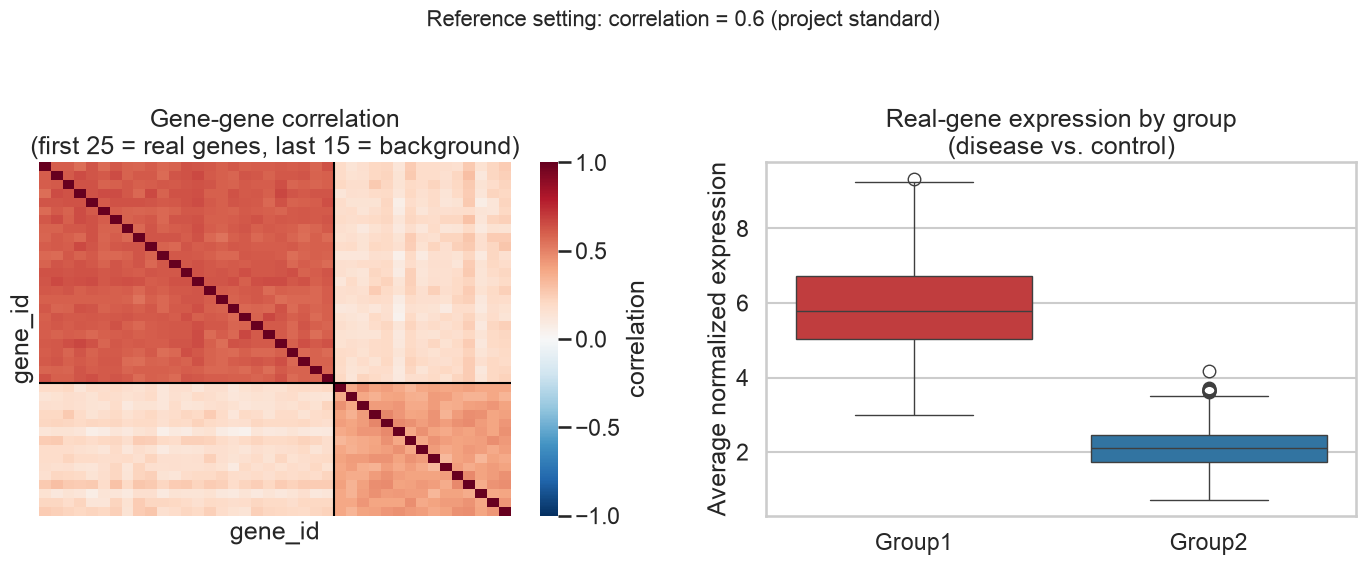

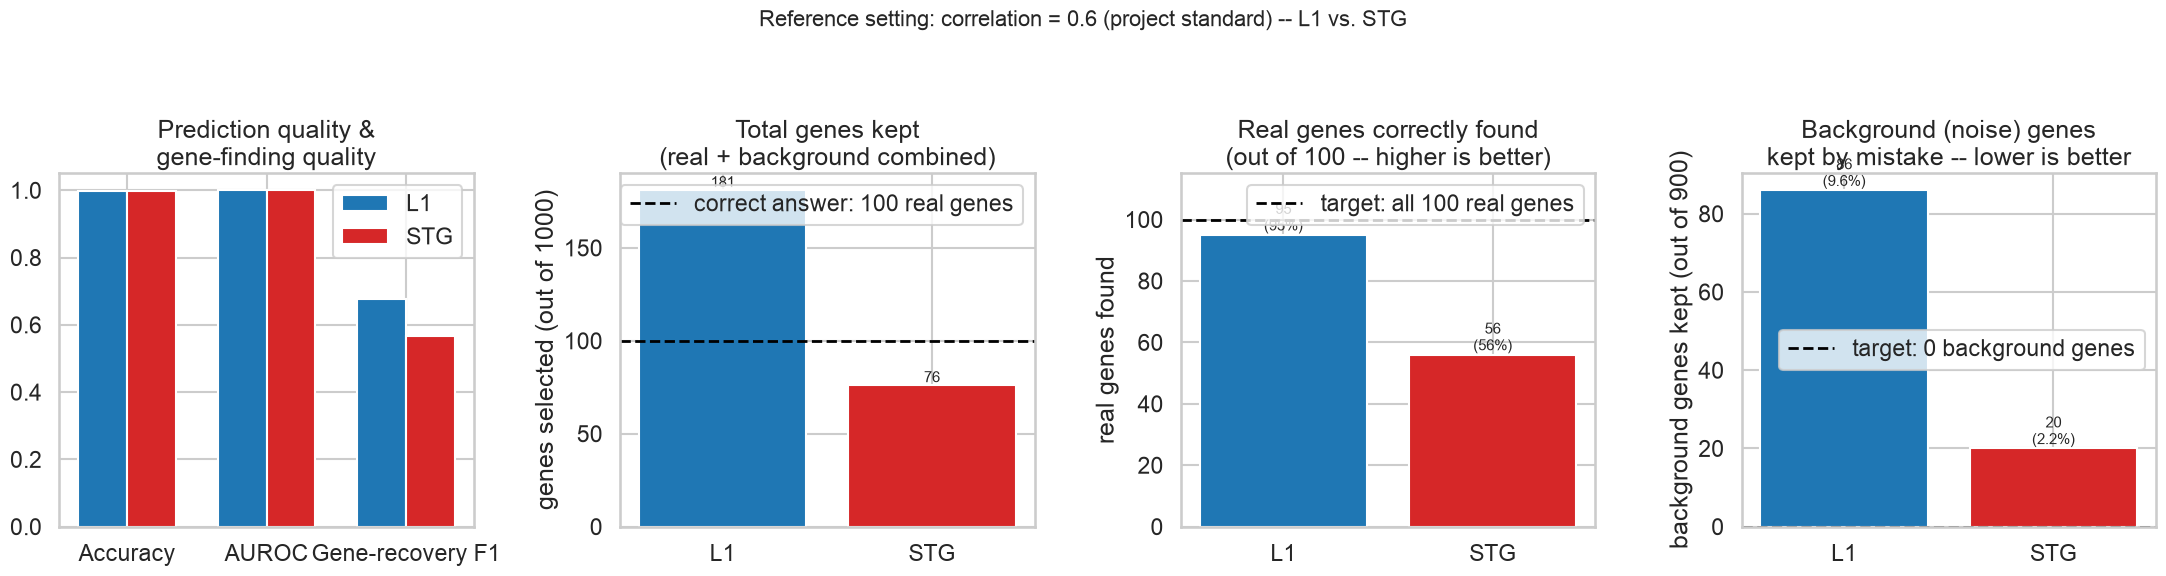

In [9]:
plot_data_overview(reference_result, "Reference setting: correlation = 0.6 (project standard)")
plot_method_comparison(reference_result, "Reference setting: correlation = 0.6 (project standard) -- L1 vs. STG")

Both methods are learning something real (accuracy well above the 50% random-guess
baseline). Setup is complete — from here on, `LAMBDA_FIXED` never changes again.

## Experiment 1: Correlation strength

**The question:** as the real genes are made to move together more strongly, does
each method get *better or worse* at finding them?

Everything else stays at the project's standard settings (signal strength,
measurement noise, patient variability) — only correlation strength changes,
across five settings: none, weak (0.2), moderate (0.4), strong (0.6 — the project's
standard), and very strong (0.8).

In [10]:
experiment1_results = {}  # setting key -> result dict, filled in below

### Experiment 1, Setting A: No correlation between genes (flat data)

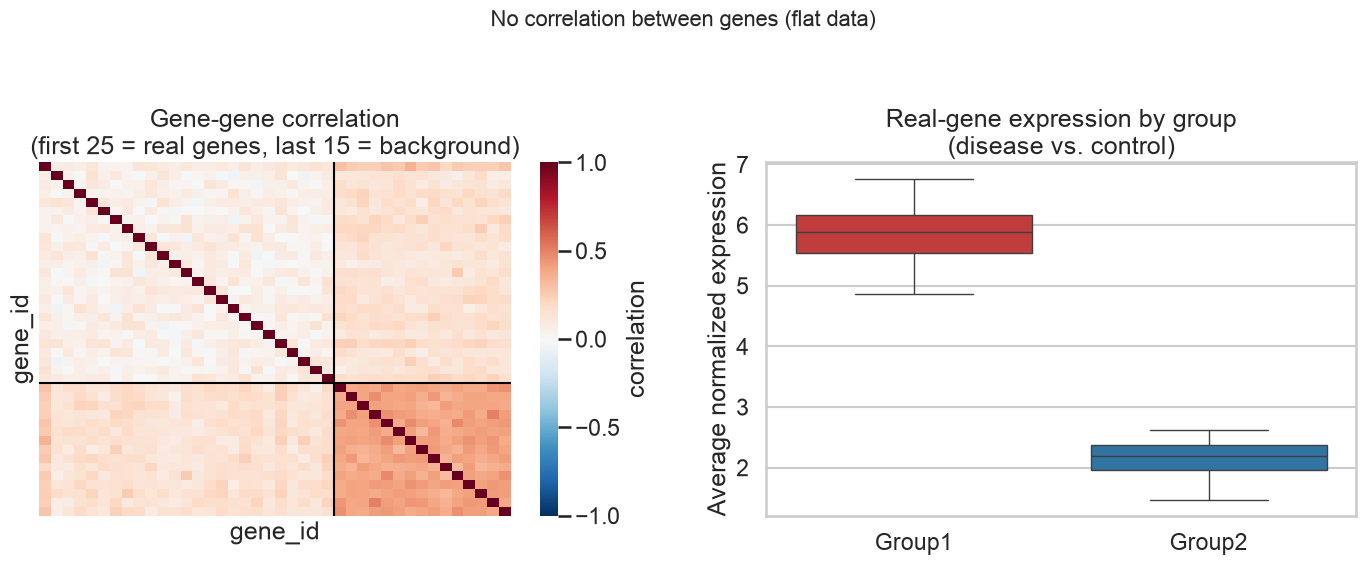

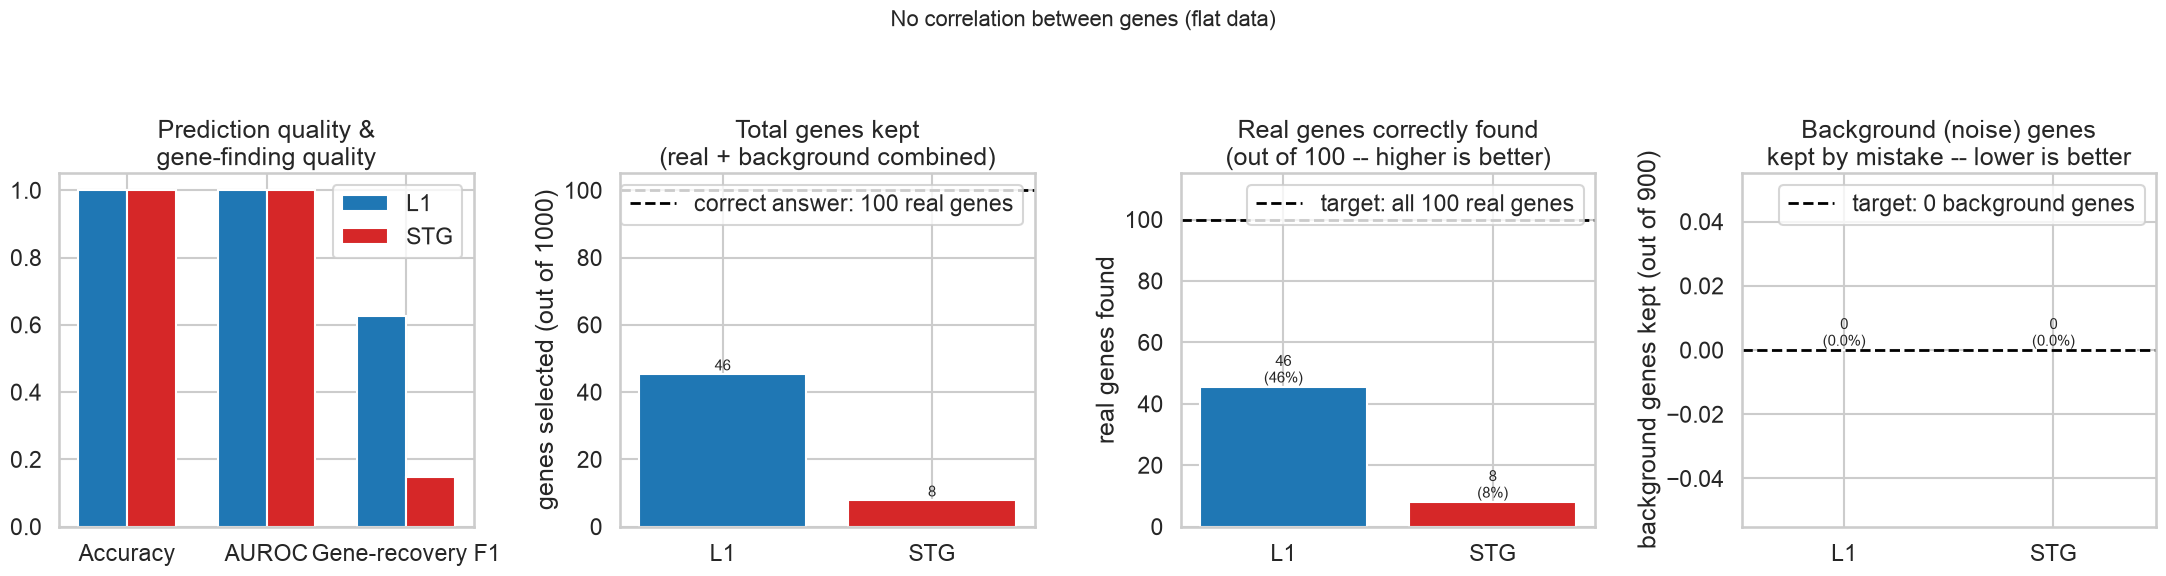

In [11]:
experiment1_results["none"] = run_condition("flat", LAMBDA_FIXED, **{})
plot_data_overview(experiment1_results["none"], "No correlation between genes (flat data)")
plot_method_comparison(experiment1_results["none"], "No correlation between genes (flat data)")

### Experiment 1, Setting B: Correlation = 0.2 (weak)

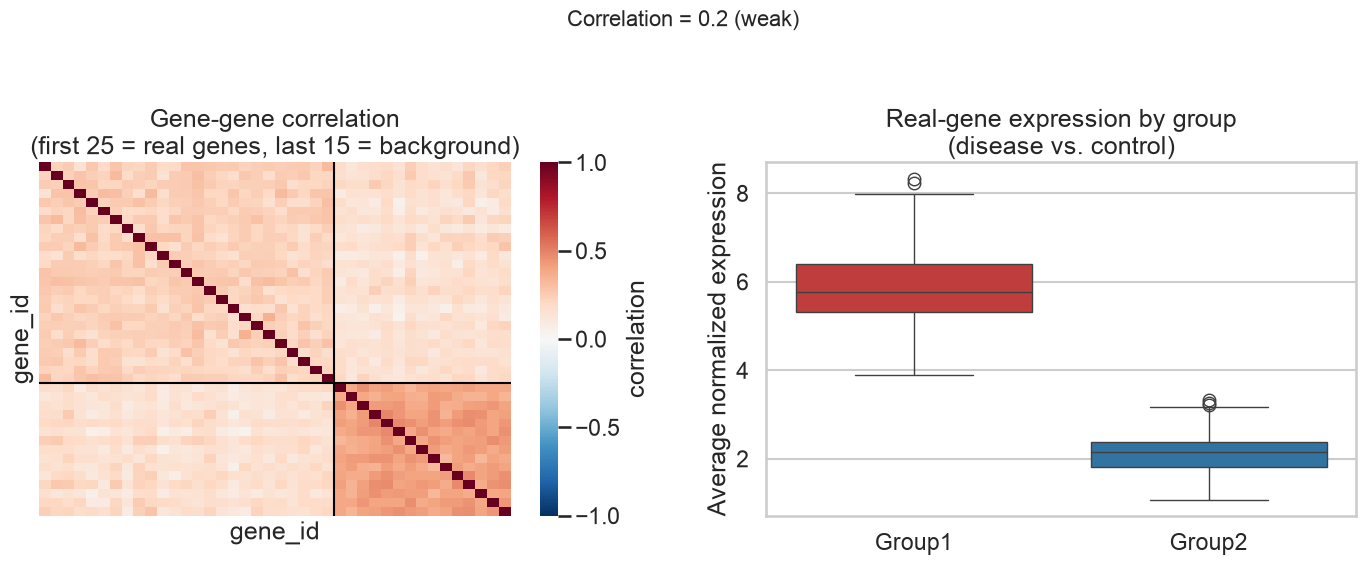

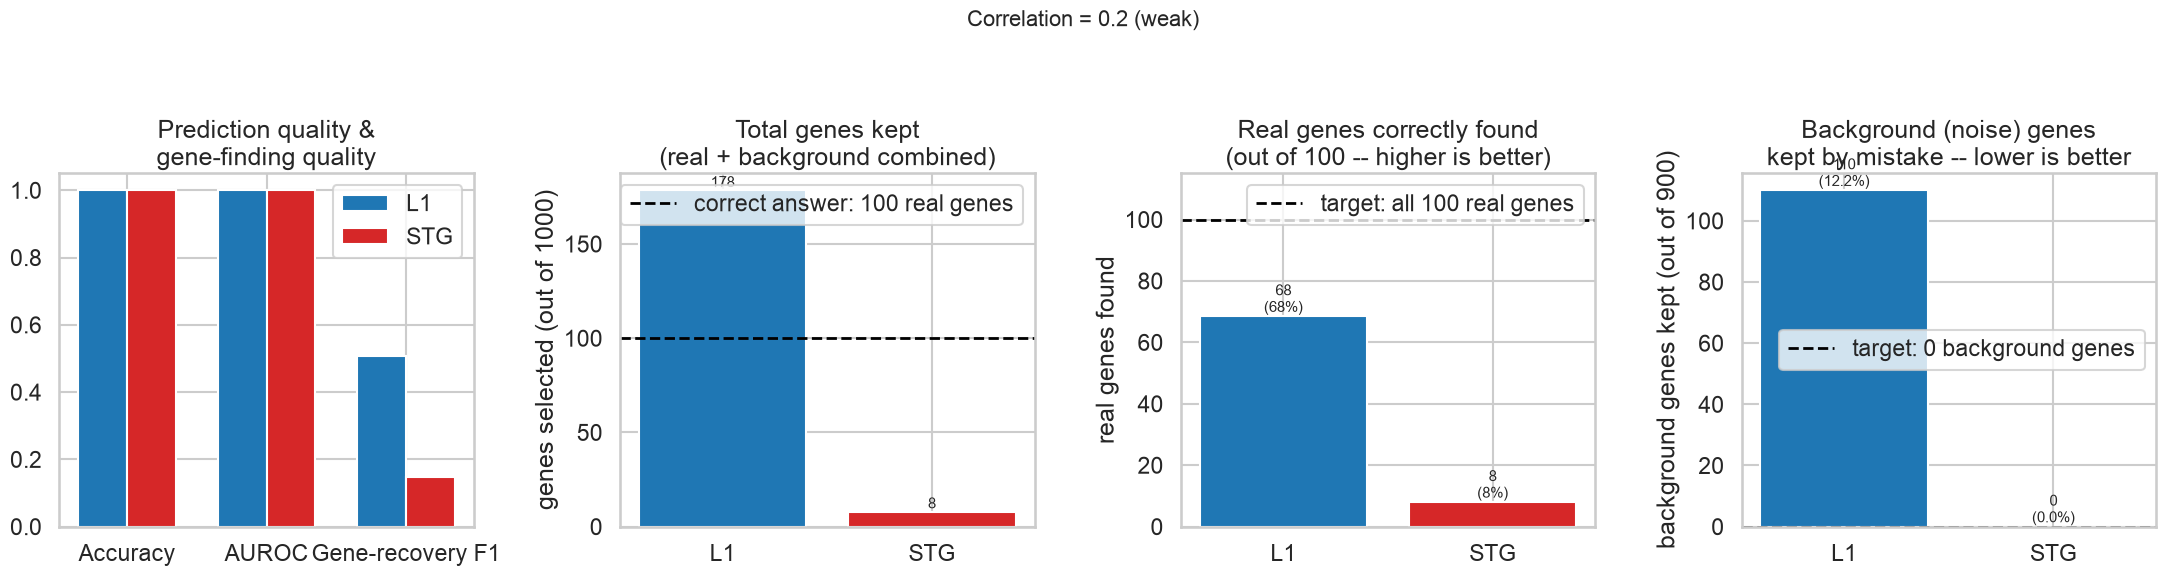

In [12]:
experiment1_results["0.2"] = run_condition("correlated", LAMBDA_FIXED, **{'within_module_correlation': 0.2})
plot_data_overview(experiment1_results["0.2"], "Correlation = 0.2 (weak)")
plot_method_comparison(experiment1_results["0.2"], "Correlation = 0.2 (weak)")

### Experiment 1, Setting C: Correlation = 0.4 (moderate)

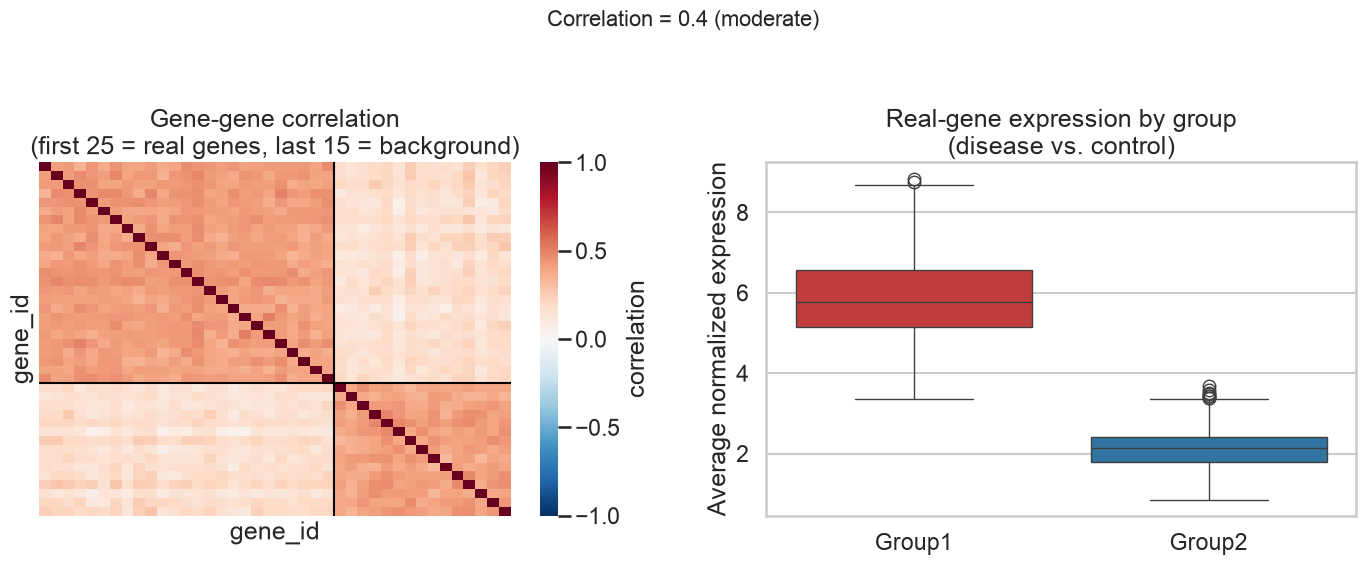

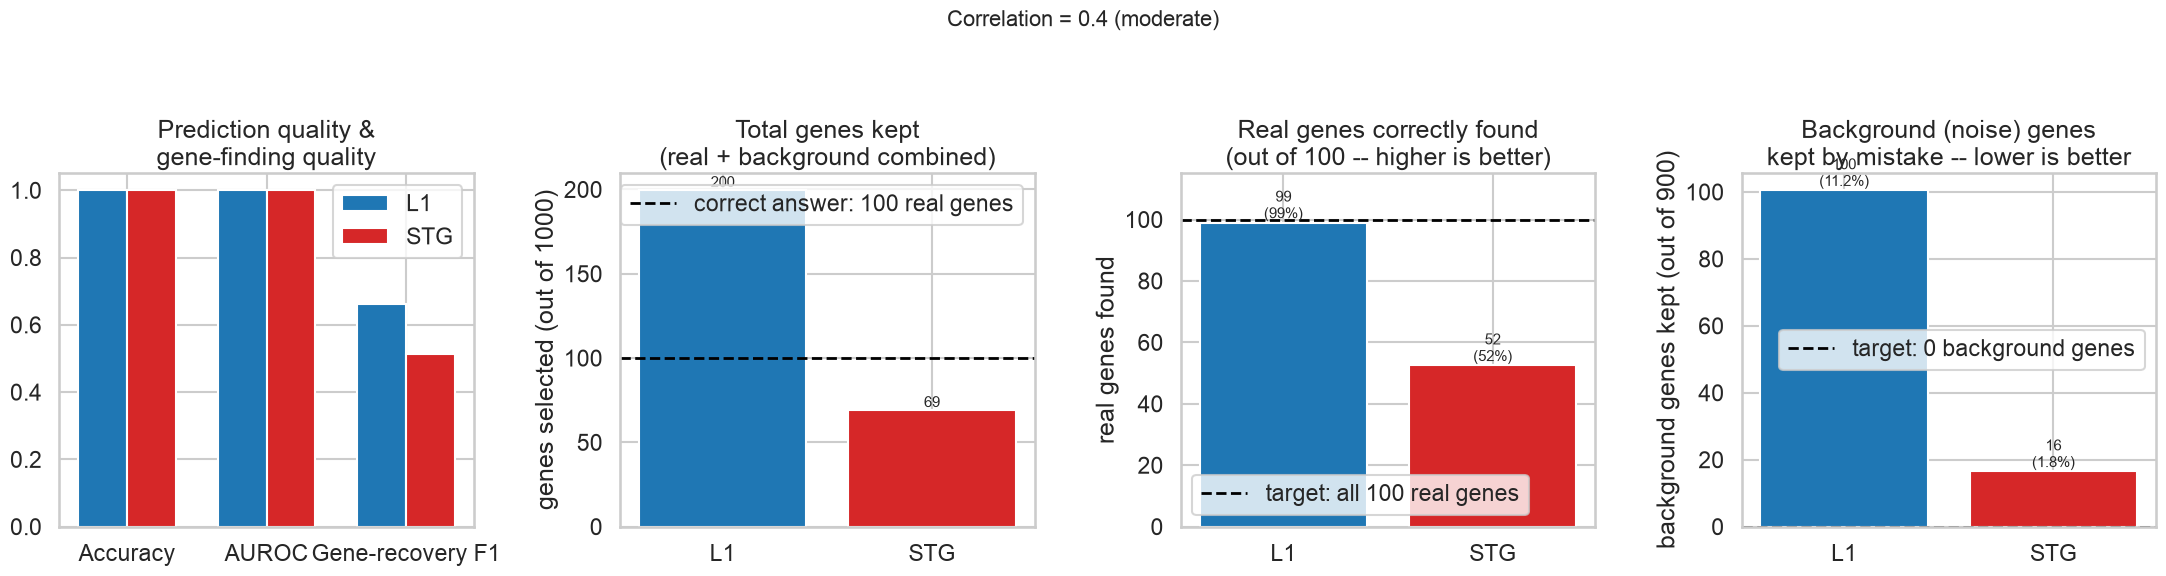

In [13]:
experiment1_results["0.4"] = run_condition("correlated", LAMBDA_FIXED, **{'within_module_correlation': 0.4})
plot_data_overview(experiment1_results["0.4"], "Correlation = 0.4 (moderate)")
plot_method_comparison(experiment1_results["0.4"], "Correlation = 0.4 (moderate)")

### Experiment 1, Setting D: Correlation = 0.6 (strong -- project standard)

This is the same reference setting run in Section 3 above — reused directly here, not recomputed, so this section is just showing that same result in its proper place in the experiment.

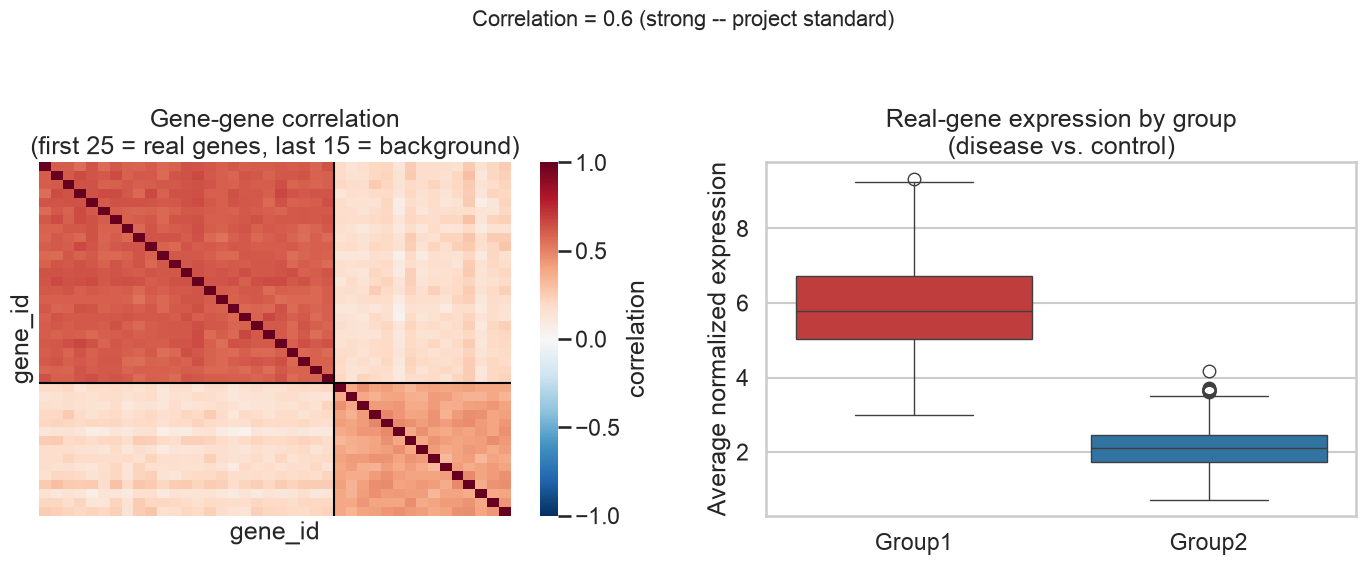

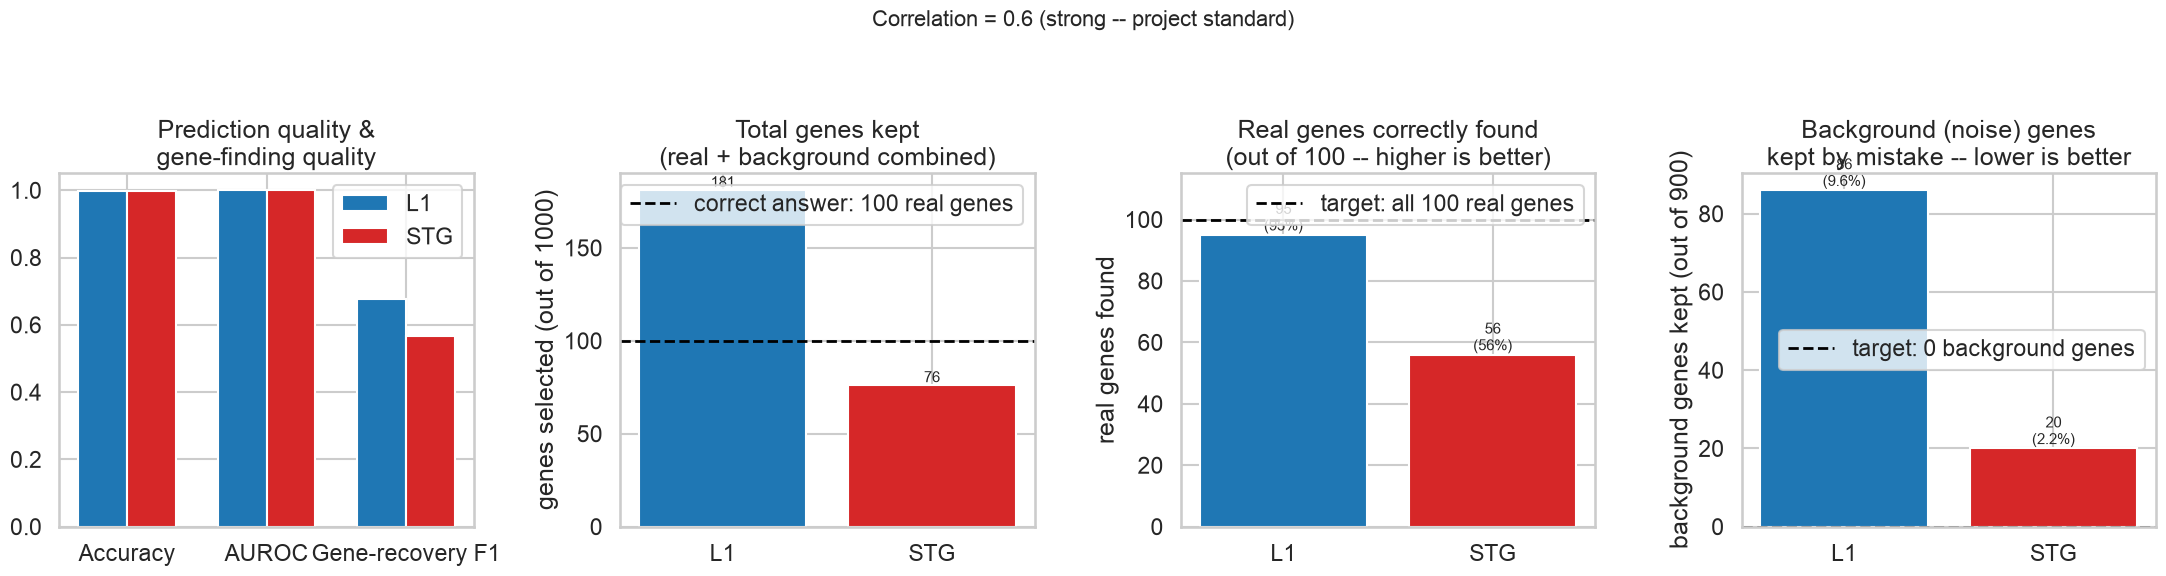

In [14]:
experiment1_results["0.6"] = reference_result
plot_data_overview(experiment1_results["0.6"], "Correlation = 0.6 (strong -- project standard)")
plot_method_comparison(experiment1_results["0.6"], "Correlation = 0.6 (strong -- project standard)")

### Experiment 1, Setting E: Correlation = 0.8 (very strong)

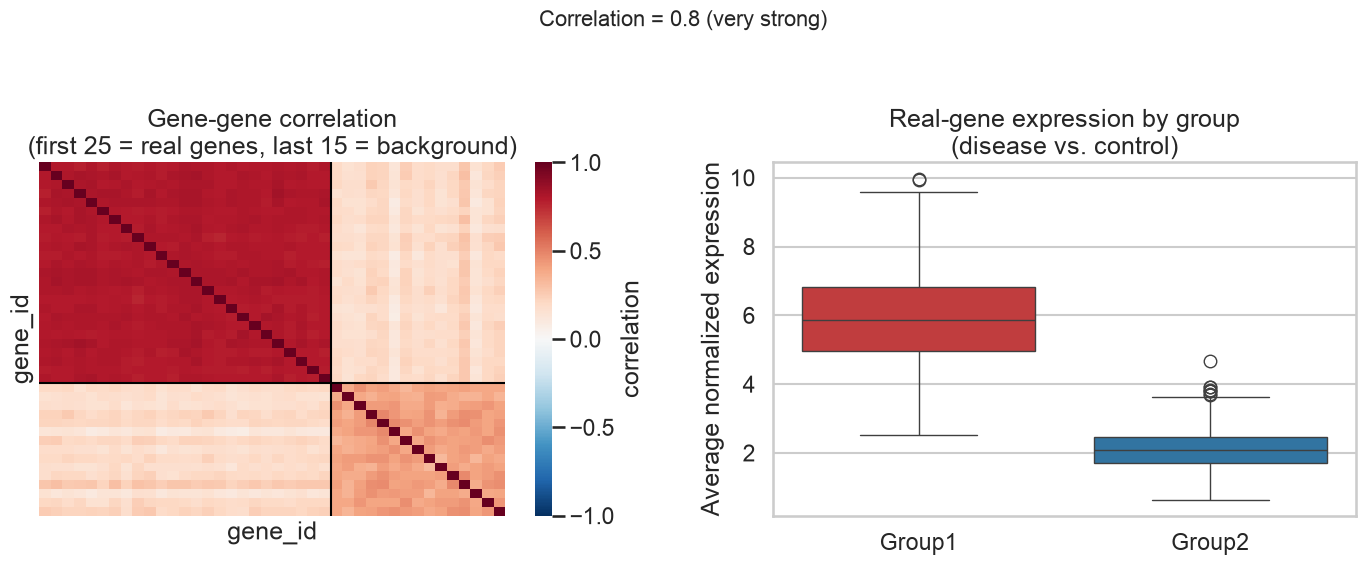

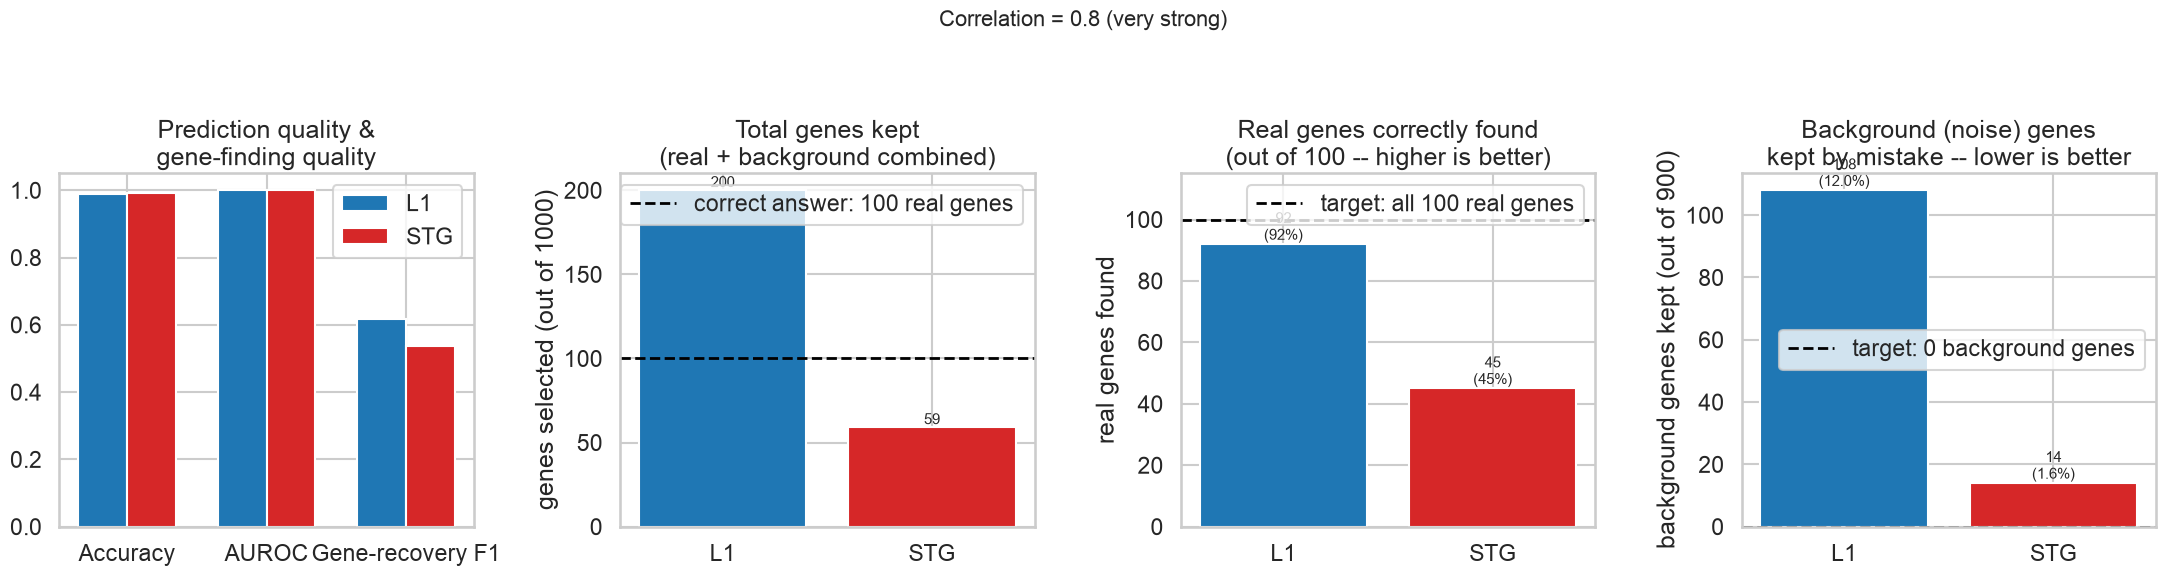

In [15]:
experiment1_results["0.8"] = run_condition("correlated", LAMBDA_FIXED, **{'within_module_correlation': 0.8})
plot_data_overview(experiment1_results["0.8"], "Correlation = 0.8 (very strong)")
plot_method_comparison(experiment1_results["0.8"], "Correlation = 0.8 (very strong)")

### Experiment 1 summary

A table of every setting's numbers side by side, plus one combined trend picture as
a bonus overview (in addition to, not instead of, the five individual pictures
above).

In [16]:
exp1_rows = []
x_labels_exp1 = {"none": 0.0, "0.2": 0.2, "0.4": 0.4, "0.6": 0.6, "0.8": 0.8}
for key, x_val in x_labels_exp1.items():
    for method in ("L1", "STG"):
        a = experiment1_results[key]["averaged"][method]
        exp1_rows.append({"correlation": x_val, "setting": key, "method": method, **a})

exp1_summary_df = pd.DataFrame(exp1_rows)
pd.set_option("display.max_columns", None)
exp1_summary_df.round(3)

,correlation,setting,method,accuracy,auroc,n_selected,precision,recall,f1,n_signal_recovered,n_background_leaked,pct_signal_recovered,pct_background_leaked
0,0.0,none,L1,1.000,1.0,45.5,1.000,0.455,0.625,45.5,0.0,45.5,0.000
1,0.0,none,STG,1.000,1.0,8.0,1.000,0.080,0.148,8.0,0.0,8.0,0.000
2,0.2,0.2,L1,1.000,1.0,178.5,0.656,0.685,0.508,68.5,110.0,68.5,12.222
3,0.2,0.2,STG,1.000,1.0,8.0,1.000,0.080,0.148,8.0,0.0,8.0,0.000
4,0.4,0.4,L1,1.000,1.0,199.5,0.496,0.990,0.661,99.0,100.5,99.0,11.167
5,0.4,0.4,STG,1.000,1.0,69.0,0.870,0.525,0.513,52.5,16.5,52.5,1.833
6,0.6,0.6,L1,0.998,1.0,181.0,0.525,0.950,0.676,95.0,86.0,95.0,9.556
7,0.6,0.6,STG,0.998,1.0,76.0,0.847,0.560,0.567,56.0,20.0,56.0,2.222
8,0.8,0.8,L1,0.990,1.0,200.0,0.466,0.920,0.617,92.0,108.0,92.0,12.000
9,0.8,0.8,STG,0.992,1.0,59.0,0.849,0.450,0.537,45.0,14.0,45.0,1.556


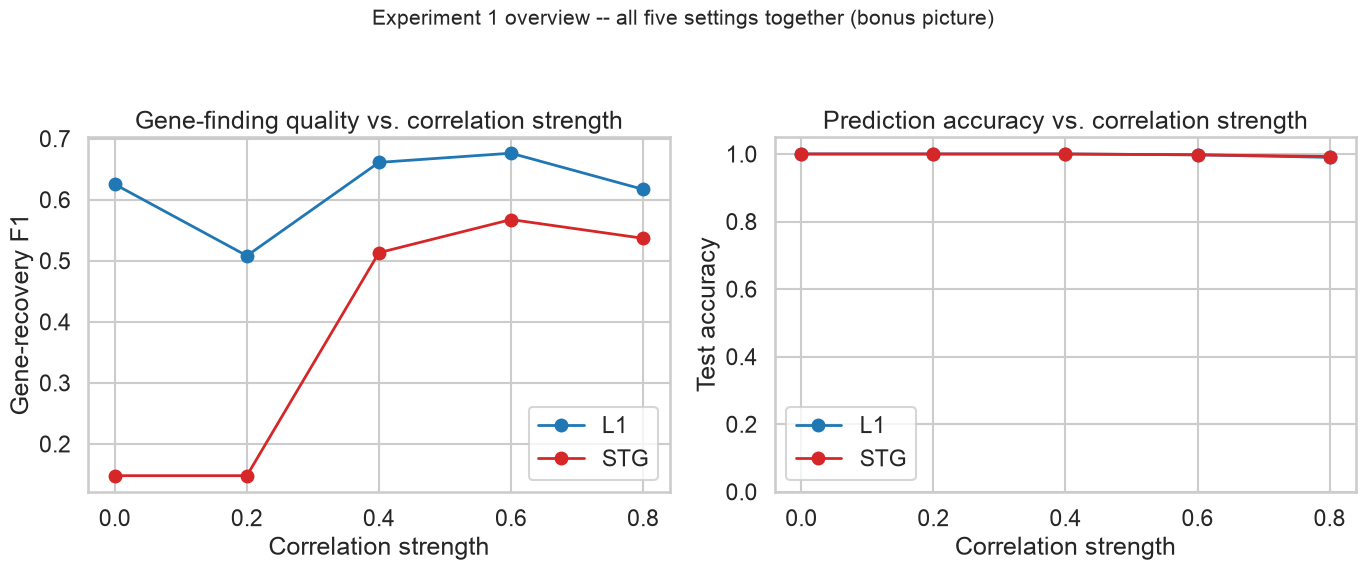

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for method in ("L1", "STG"):
    sub = exp1_summary_df[exp1_summary_df["method"] == method].sort_values("correlation")
    axes[0].plot(sub["correlation"], sub["f1"], marker="o", linewidth=2, label=method, color=METHOD_COLORS[method])
    axes[1].plot(sub["correlation"], sub["accuracy"], marker="o", linewidth=2, label=method, color=METHOD_COLORS[method])

axes[0].set_xlabel("Correlation strength")
axes[0].set_ylabel("Gene-recovery F1")
axes[0].set_title("Gene-finding quality vs. correlation strength")
axes[0].legend()

axes[1].set_xlabel("Correlation strength")
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Prediction accuracy vs. correlation strength")
axes[1].legend()
axes[1].set_ylim(0, 1.05)

fig.suptitle("Experiment 1 overview -- all five settings together (bonus picture)", y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

## Experiment 2: Signal strength (fold change)

**The question:** how much stronger does a disease patient's real-gene expression
need to be, on average, before each method can reliably find those genes — and
does the answer change depending on whether the real genes are correlated with
each other or not?

This experiment is split into two parallel parts, run back to back:

- **Part 1: Flat data** — no correlation between the real genes at all (the same
  kind of data as Experiment 1's "no correlation" setting).
- **Part 2: Correlated data** — the real genes correlated at 0.6, the project's
  standard strength (the same setting used throughout Experiment 1's "0.6" and the
  one-time setup).

Both parts sweep the exact same five signal-strength settings — 2x, 4x, 6x, 8x,
and 10x higher expression in disease patients than controls — so the two parts can
be compared directly at the end to see whether correlation structure changes how
sensitive each method is to signal strength.

### Experiment 2, Part 1: Flat data (no correlation between real genes)

In [18]:
experiment2_flat_results = {}  # setting key -> result dict, filled in below

#### Experiment 2, Part 1 (Flat data), Setting A: Fold change = 2x (mild signal)

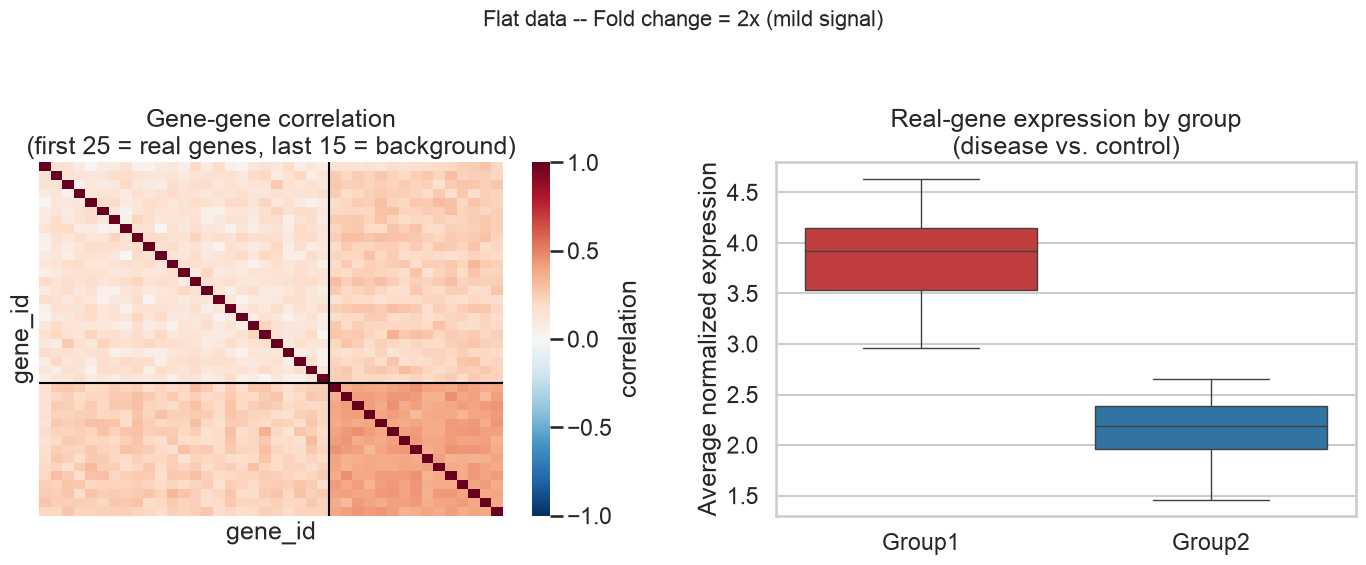

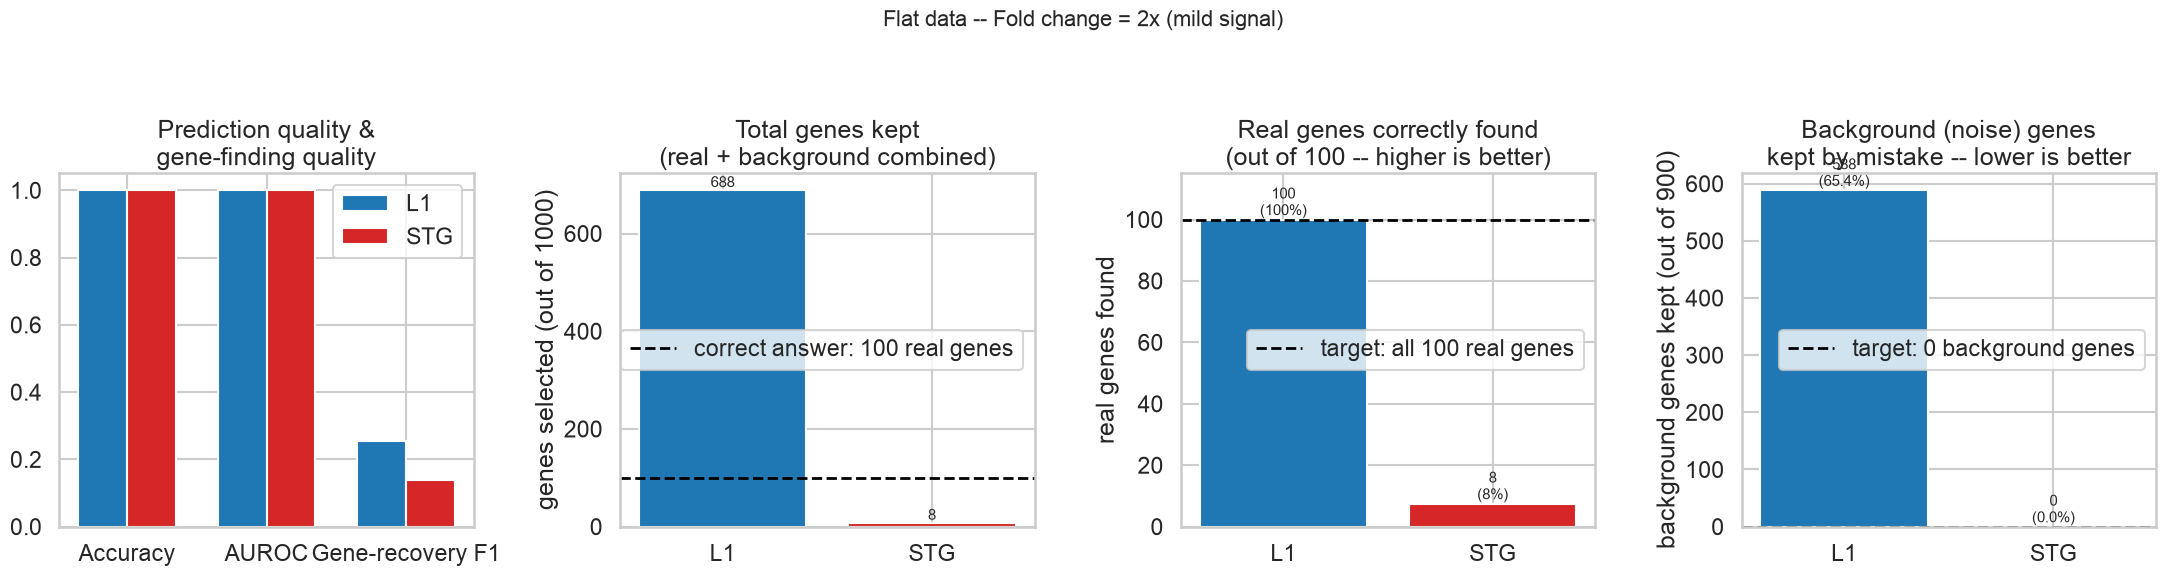

In [19]:
experiment2_flat_results["2"] = run_condition("flat", LAMBDA_FIXED, **{"fold_change": 2})
plot_data_overview(experiment2_flat_results["2"], "Flat data -- Fold change = 2x (mild signal)")
plot_method_comparison(experiment2_flat_results["2"], "Flat data -- Fold change = 2x (mild signal)")

#### Experiment 2, Part 1 (Flat data), Setting B: Fold change = 4x (moderate)

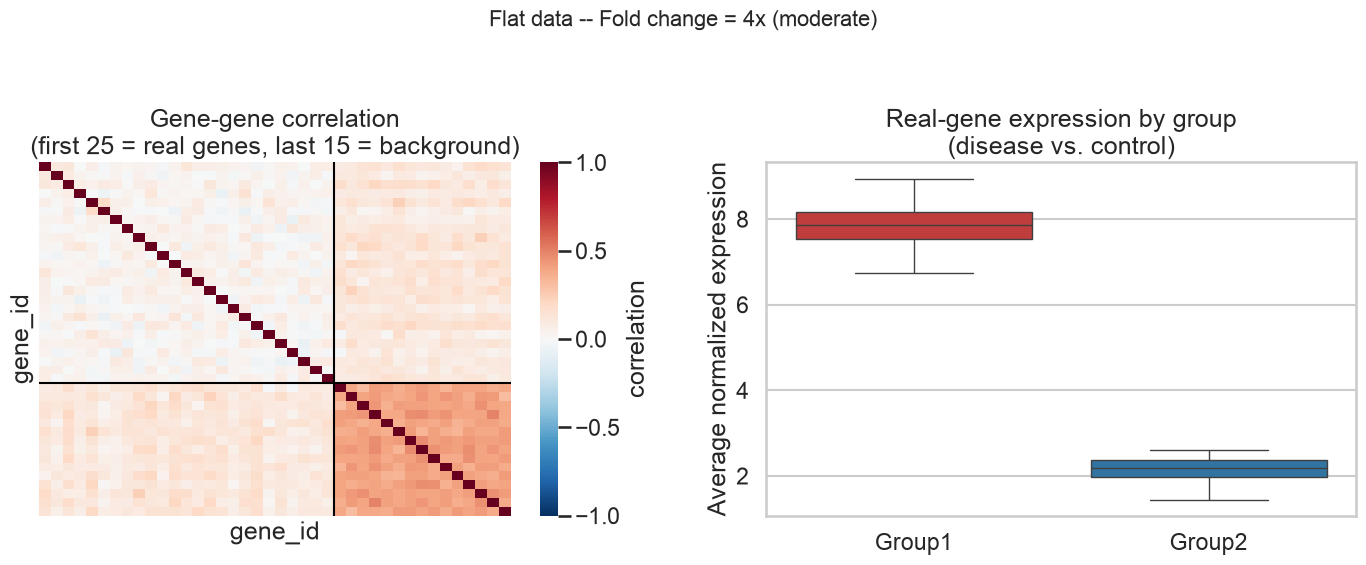

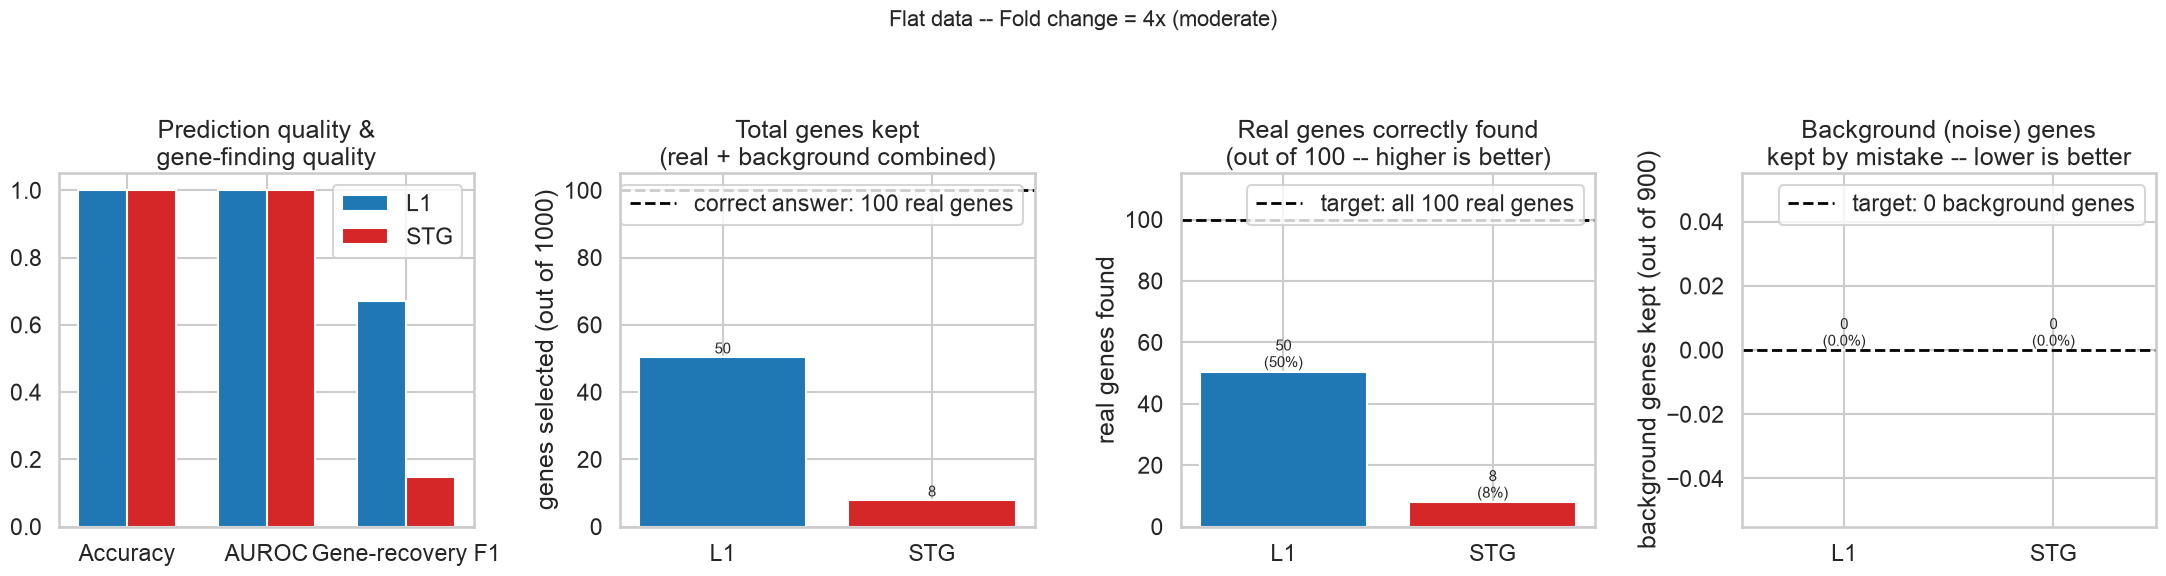

In [20]:
experiment2_flat_results["4"] = run_condition("flat", LAMBDA_FIXED, **{"fold_change": 4})
plot_data_overview(experiment2_flat_results["4"], "Flat data -- Fold change = 4x (moderate)")
plot_method_comparison(experiment2_flat_results["4"], "Flat data -- Fold change = 4x (moderate)")

#### Experiment 2, Part 1 (Flat data), Setting C: Fold change = 6x (strong)

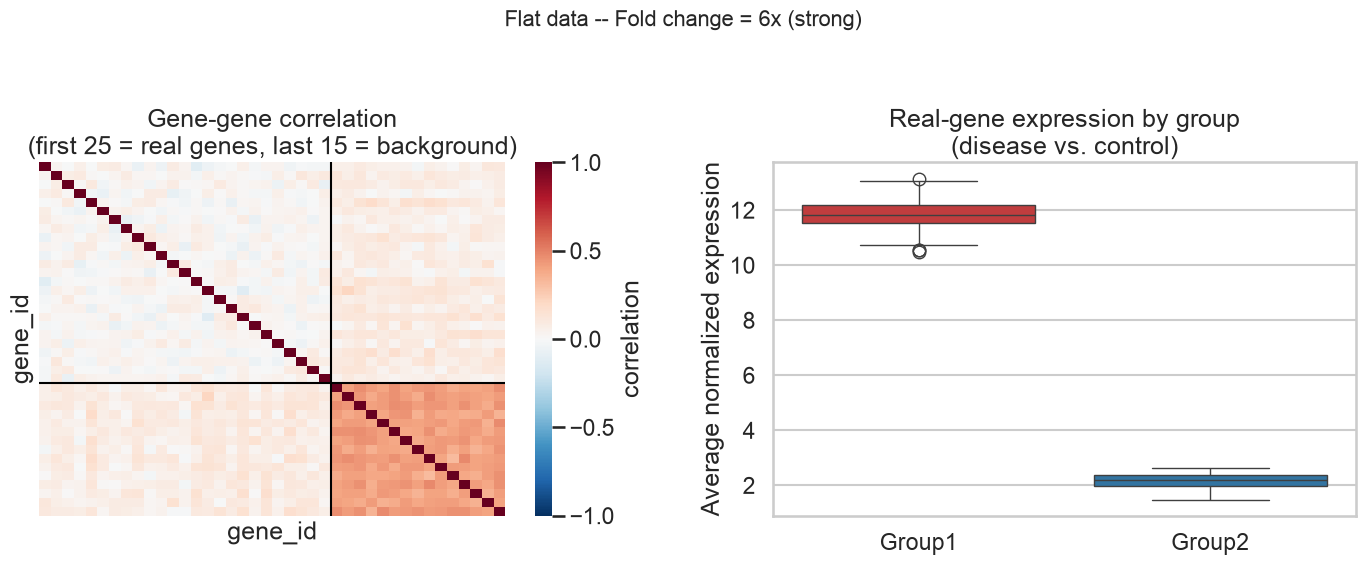

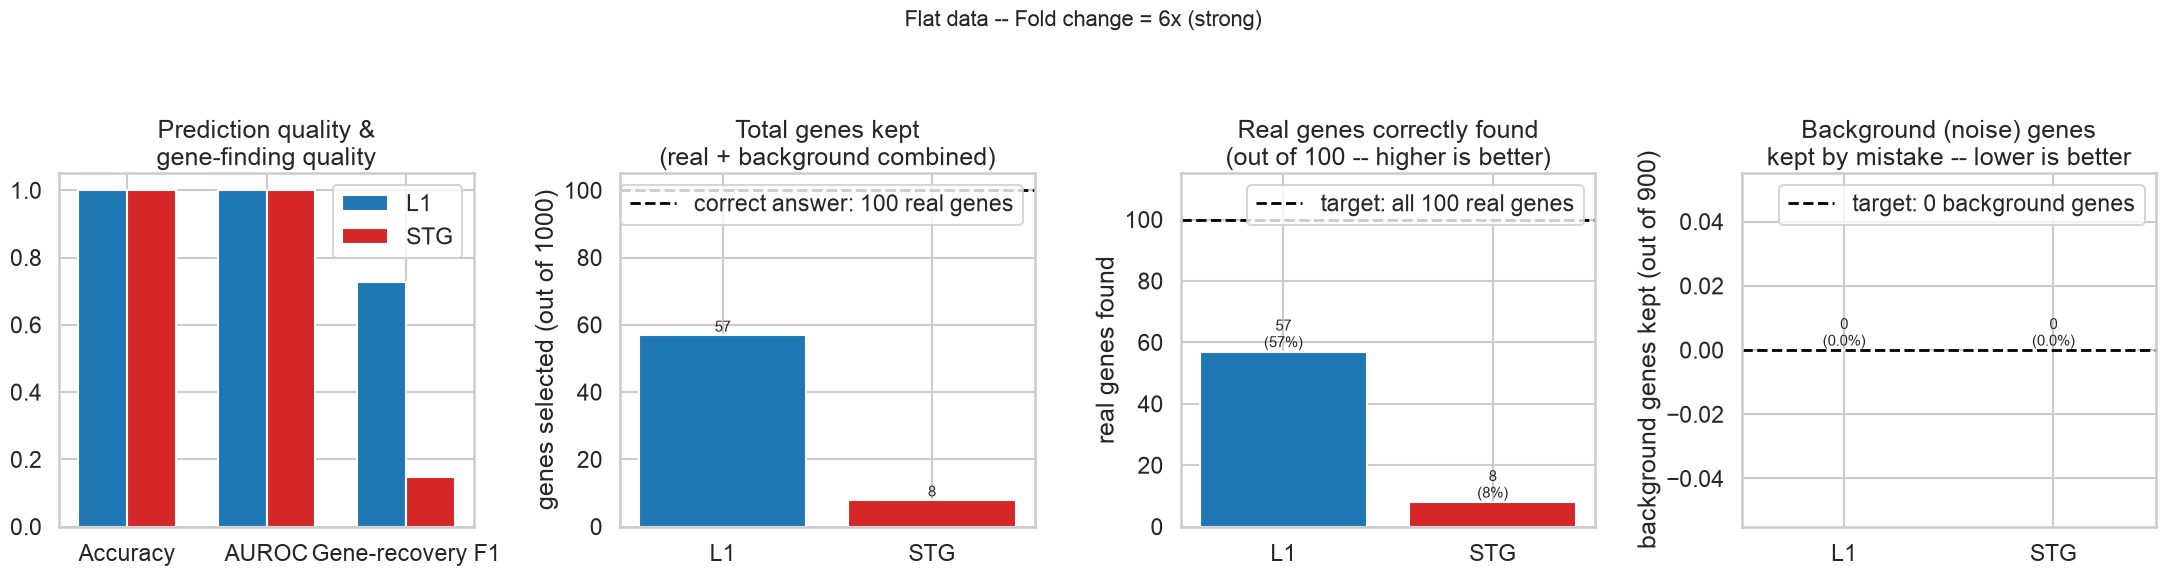

In [21]:
experiment2_flat_results["6"] = run_condition("flat", LAMBDA_FIXED, **{"fold_change": 6})
plot_data_overview(experiment2_flat_results["6"], "Flat data -- Fold change = 6x (strong)")
plot_method_comparison(experiment2_flat_results["6"], "Flat data -- Fold change = 6x (strong)")

#### Experiment 2, Part 1 (Flat data), Setting D: Fold change = 8x (very strong)

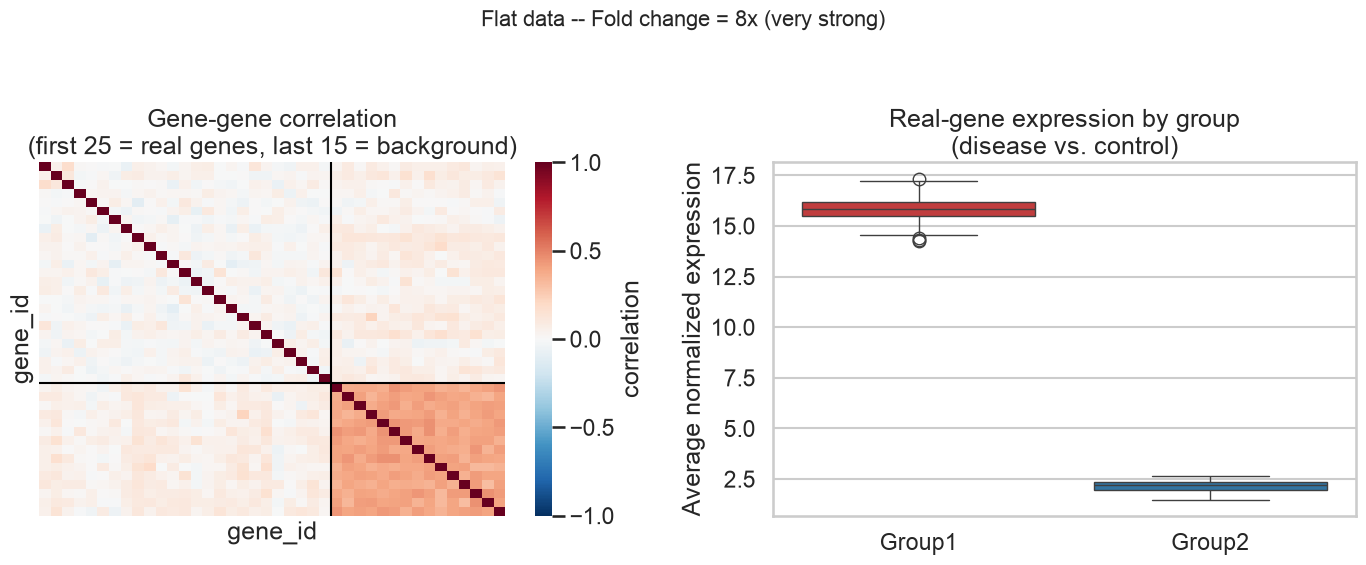

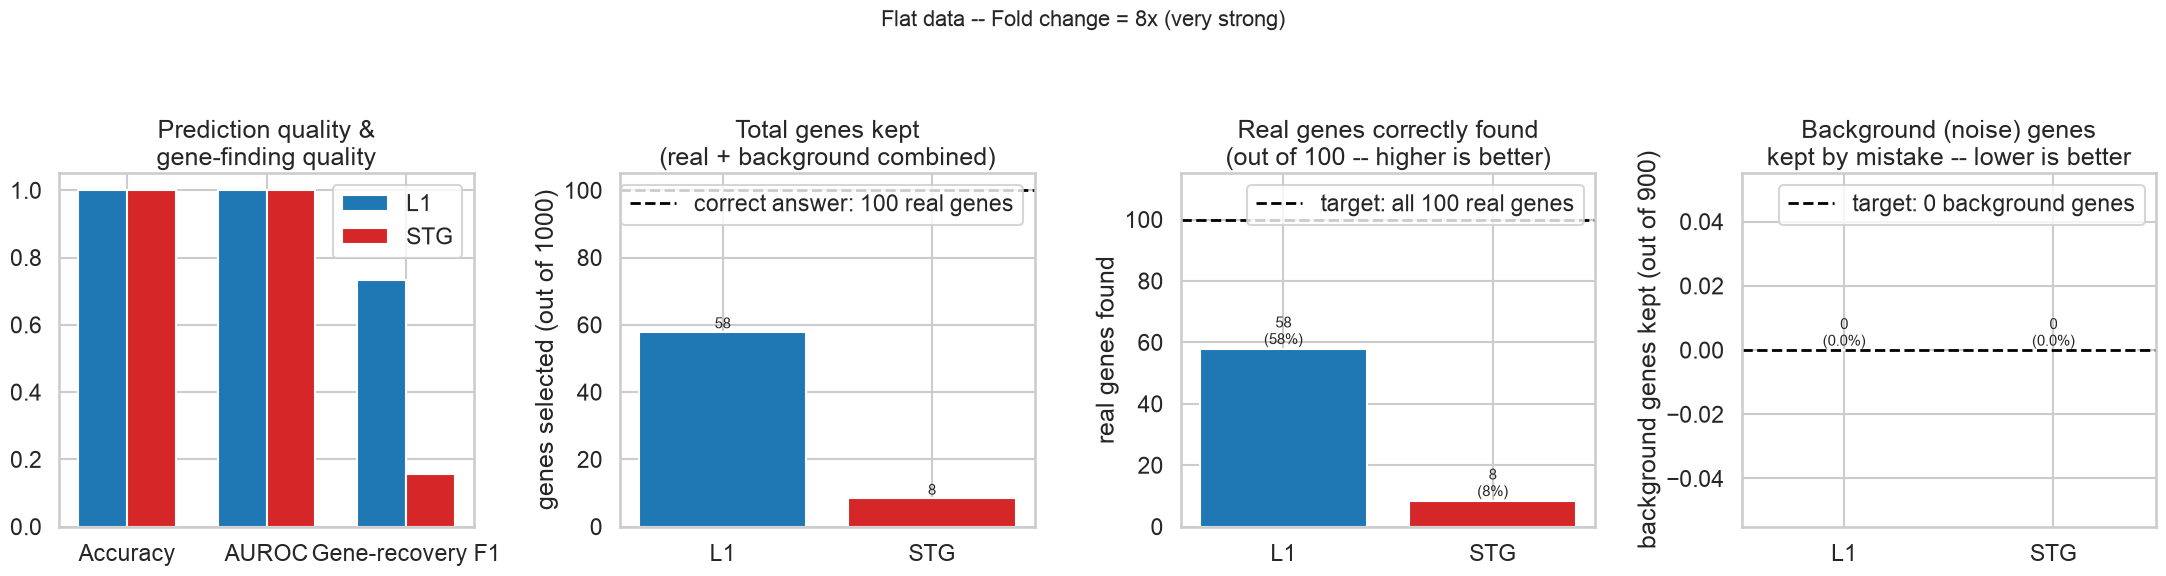

In [22]:
experiment2_flat_results["8"] = run_condition("flat", LAMBDA_FIXED, **{"fold_change": 8})
plot_data_overview(experiment2_flat_results["8"], "Flat data -- Fold change = 8x (very strong)")
plot_method_comparison(experiment2_flat_results["8"], "Flat data -- Fold change = 8x (very strong)")

#### Experiment 2, Part 1 (Flat data), Setting E: Fold change = 10x (extreme)

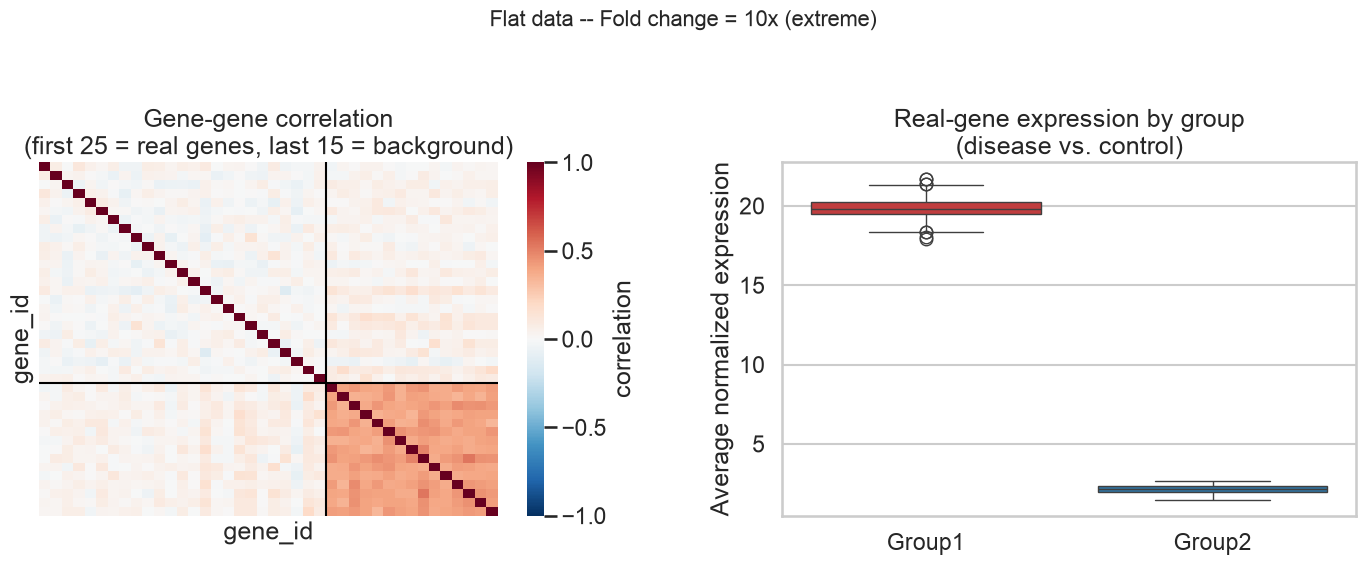

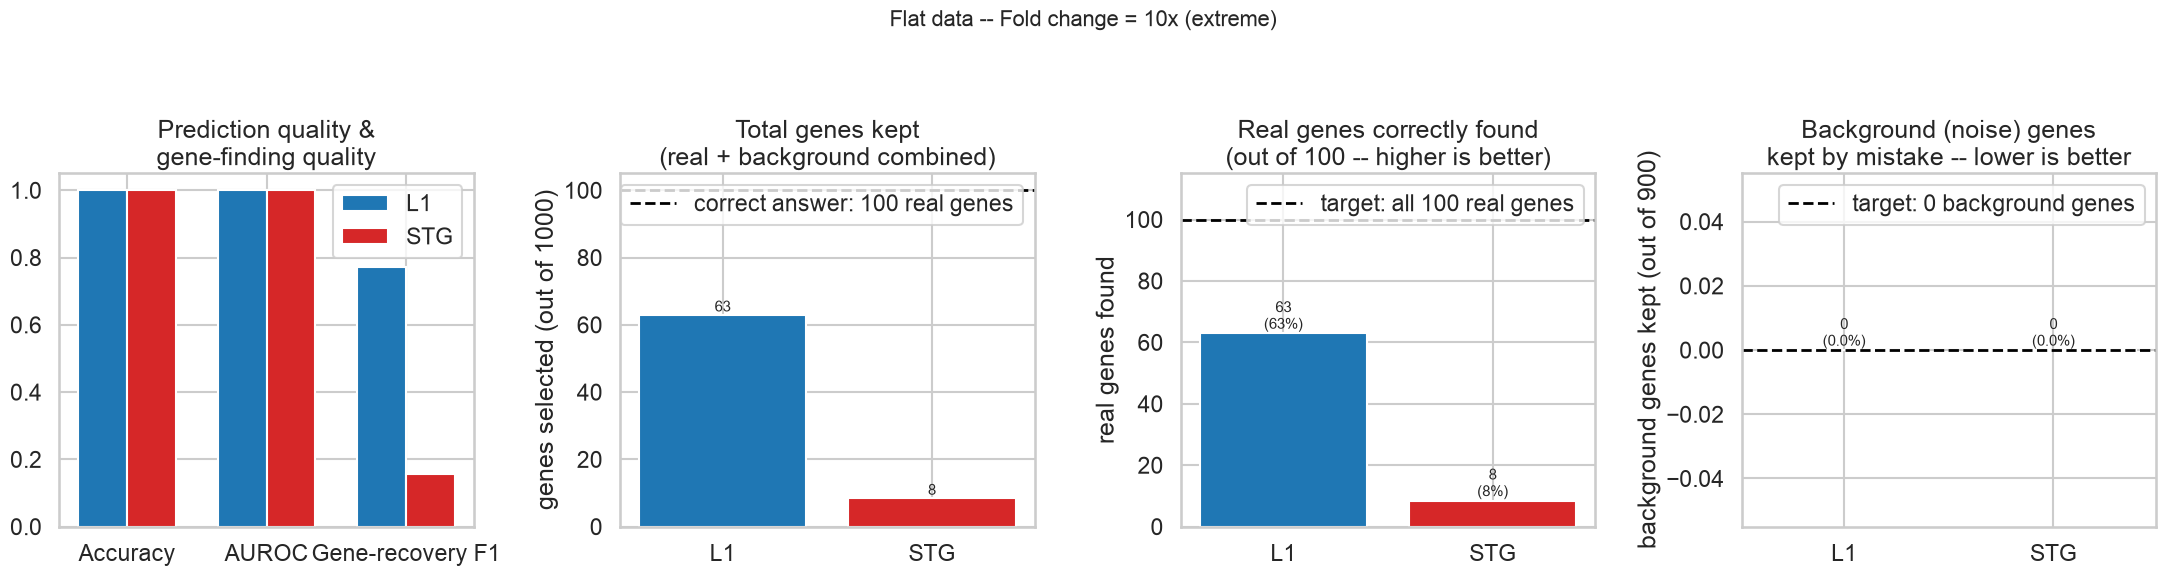

In [23]:
experiment2_flat_results["10"] = run_condition("flat", LAMBDA_FIXED, **{"fold_change": 10})
plot_data_overview(experiment2_flat_results["10"], "Flat data -- Fold change = 10x (extreme)")
plot_method_comparison(experiment2_flat_results["10"], "Flat data -- Fold change = 10x (extreme)")

### Experiment 2, Part 2: Correlated data (real genes correlated at 0.6, the project standard)

In [24]:
experiment2_correlated_results = {}  # setting key -> result dict, filled in below

#### Experiment 2, Part 2 (Correlated data), Setting A: Fold change = 2x (mild signal)

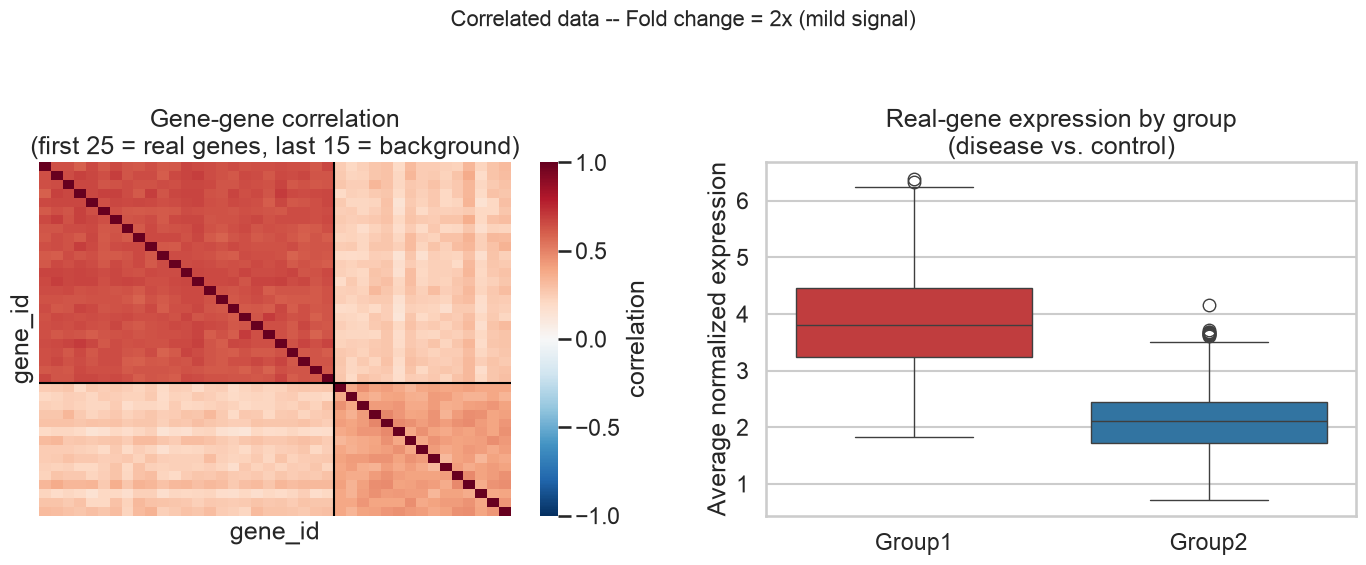

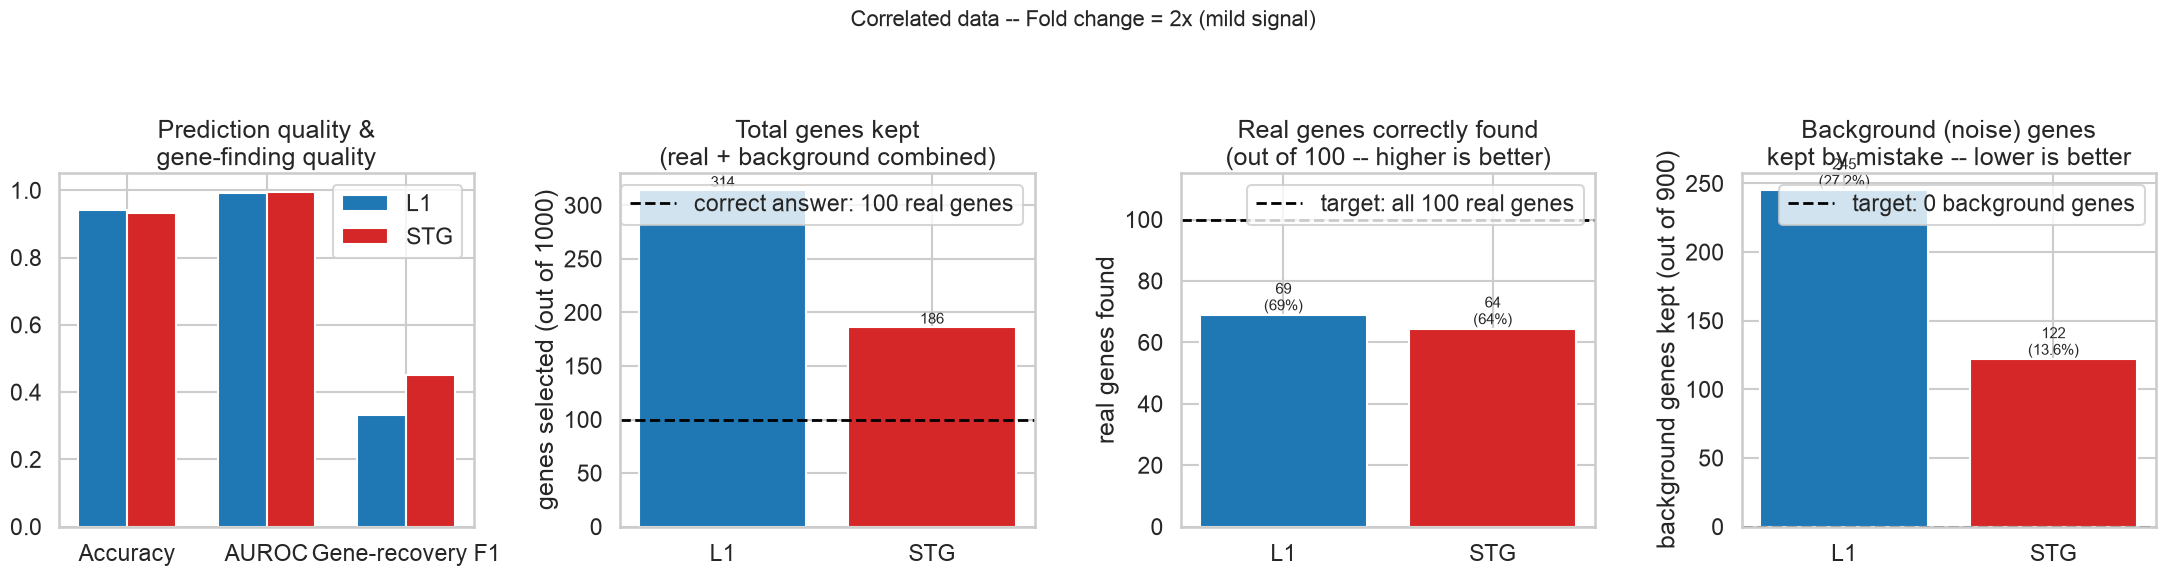

In [25]:
experiment2_correlated_results["2"] = run_condition("correlated", LAMBDA_FIXED, **{"fold_change": 2})
plot_data_overview(experiment2_correlated_results["2"], "Correlated data -- Fold change = 2x (mild signal)")
plot_method_comparison(experiment2_correlated_results["2"], "Correlated data -- Fold change = 2x (mild signal)")

#### Experiment 2, Part 2 (Correlated data), Setting B: Fold change = 4x (moderate)

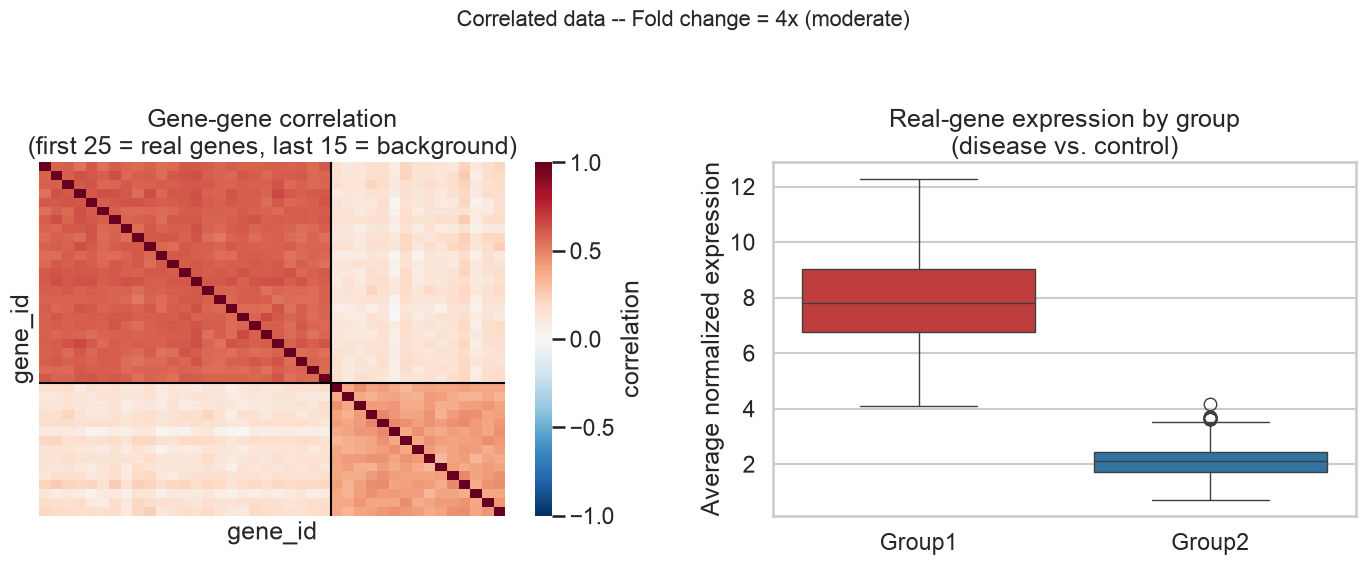

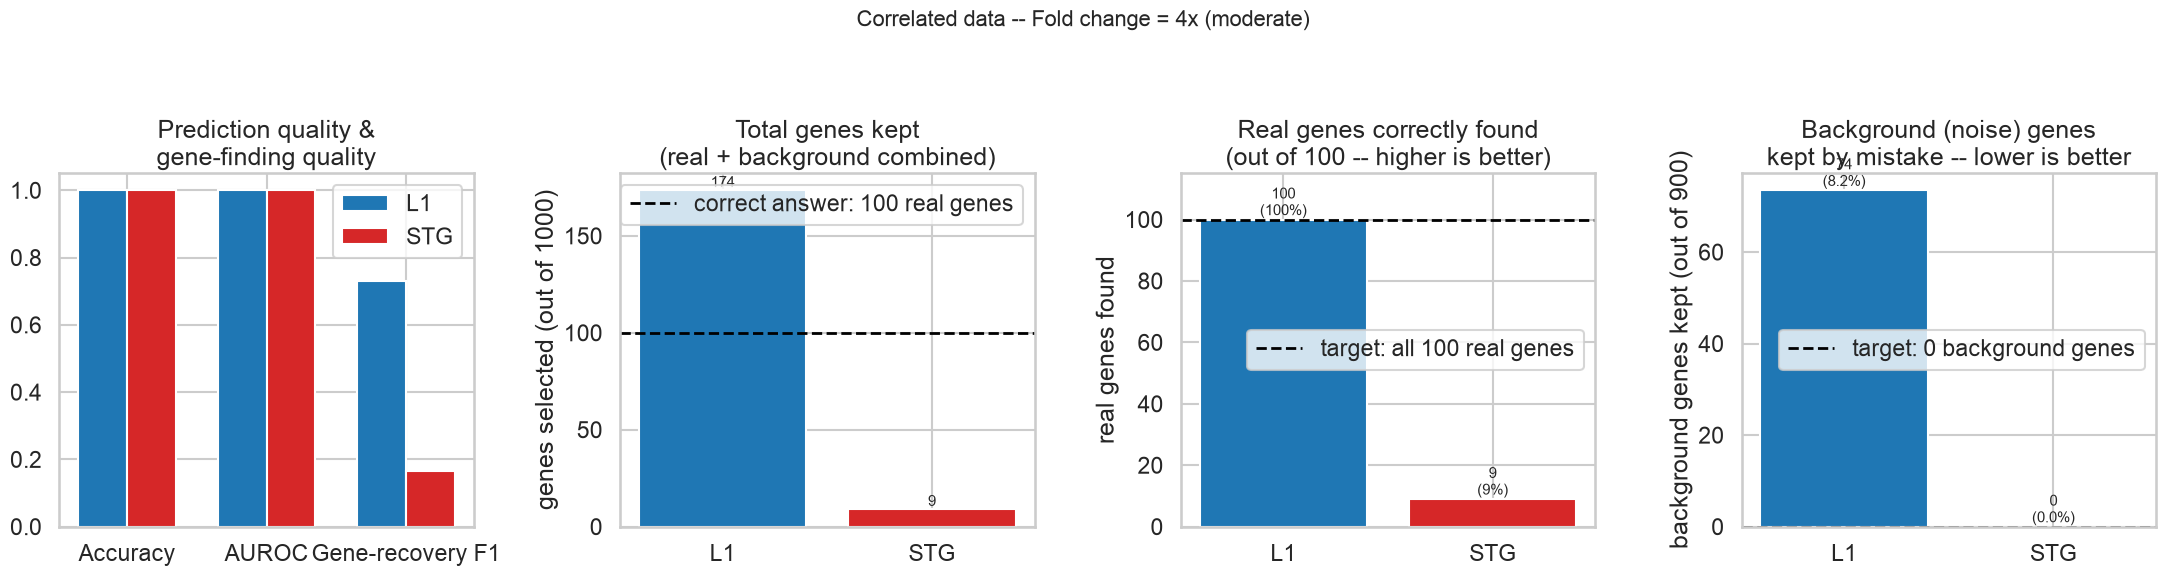

In [26]:
experiment2_correlated_results["4"] = run_condition("correlated", LAMBDA_FIXED, **{"fold_change": 4})
plot_data_overview(experiment2_correlated_results["4"], "Correlated data -- Fold change = 4x (moderate)")
plot_method_comparison(experiment2_correlated_results["4"], "Correlated data -- Fold change = 4x (moderate)")

#### Experiment 2, Part 2 (Correlated data), Setting C: Fold change = 6x (strong)

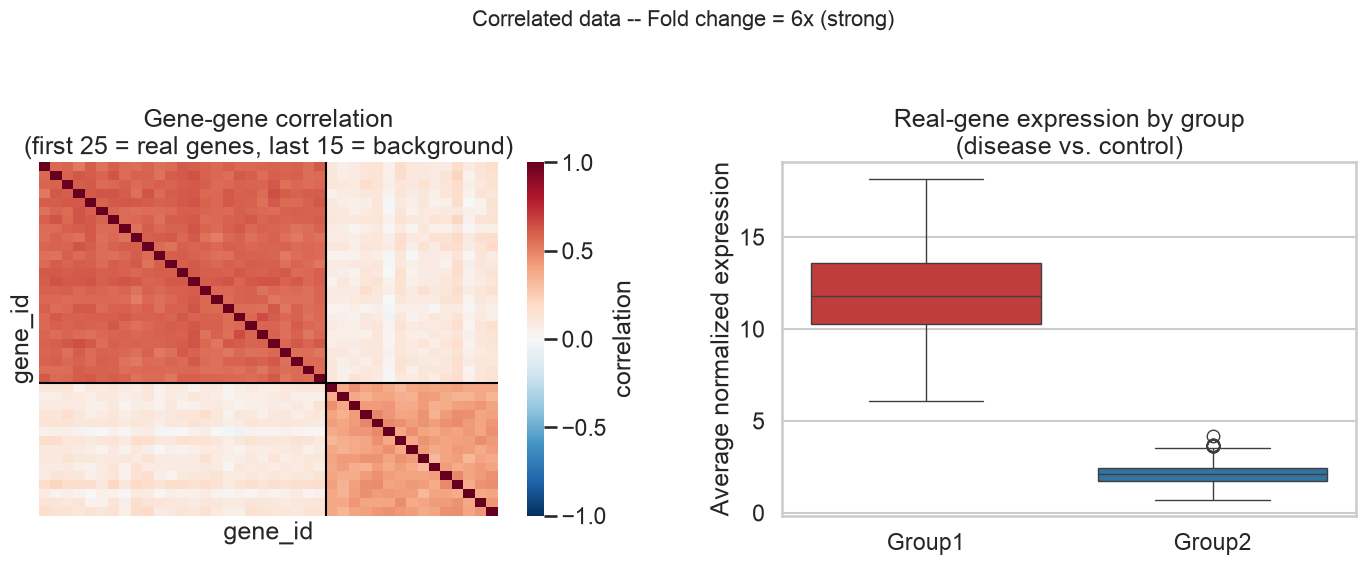

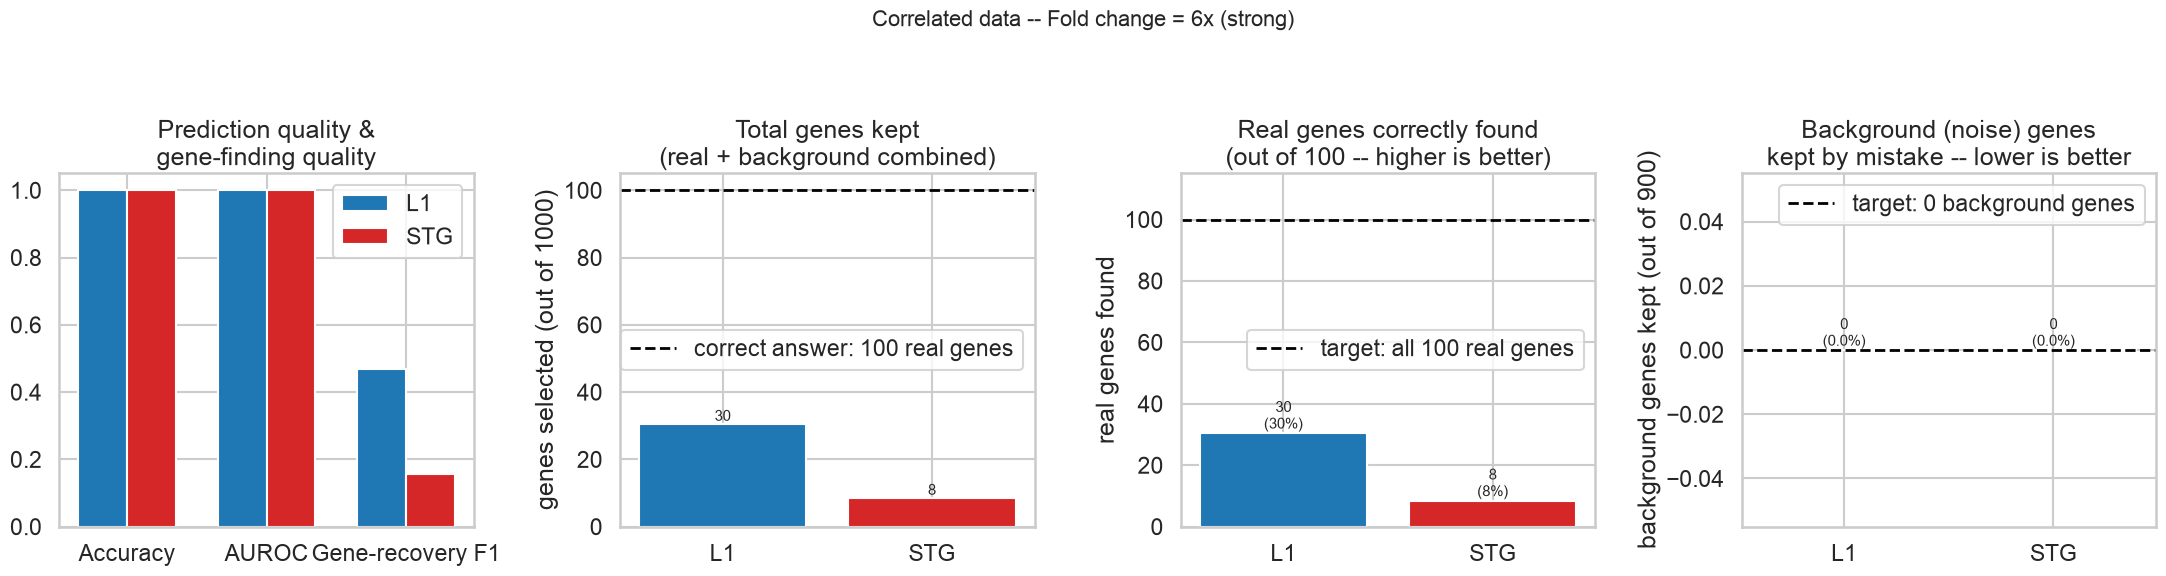

In [27]:
experiment2_correlated_results["6"] = run_condition("correlated", LAMBDA_FIXED, **{"fold_change": 6})
plot_data_overview(experiment2_correlated_results["6"], "Correlated data -- Fold change = 6x (strong)")
plot_method_comparison(experiment2_correlated_results["6"], "Correlated data -- Fold change = 6x (strong)")

#### Experiment 2, Part 2 (Correlated data), Setting D: Fold change = 8x (very strong)

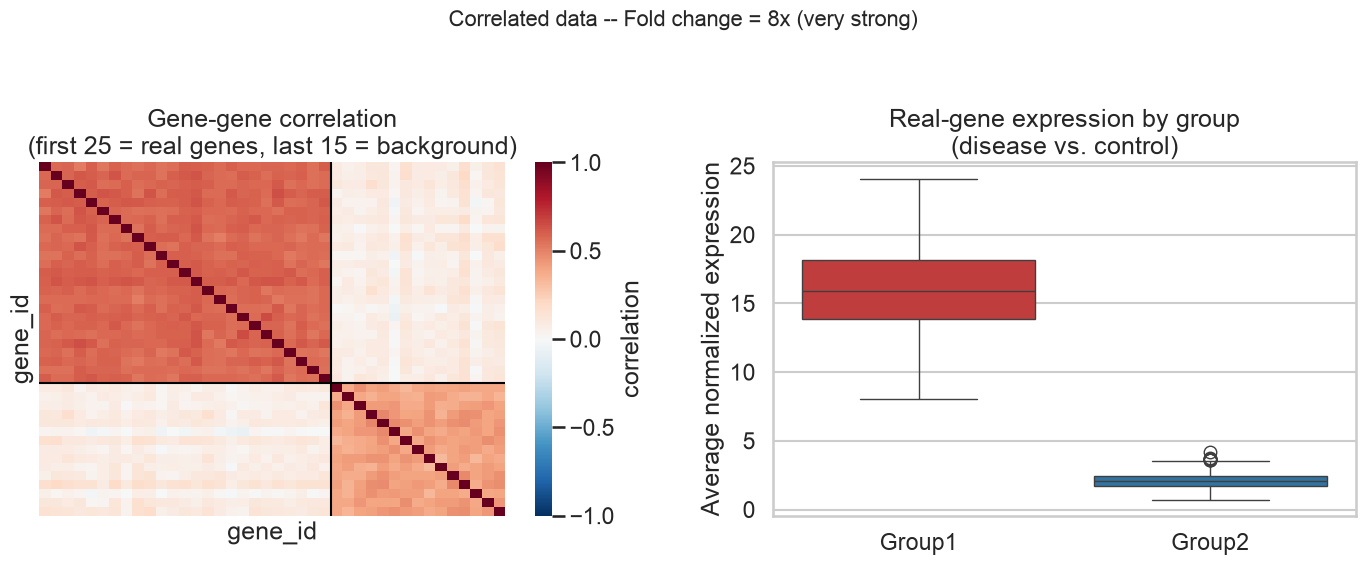

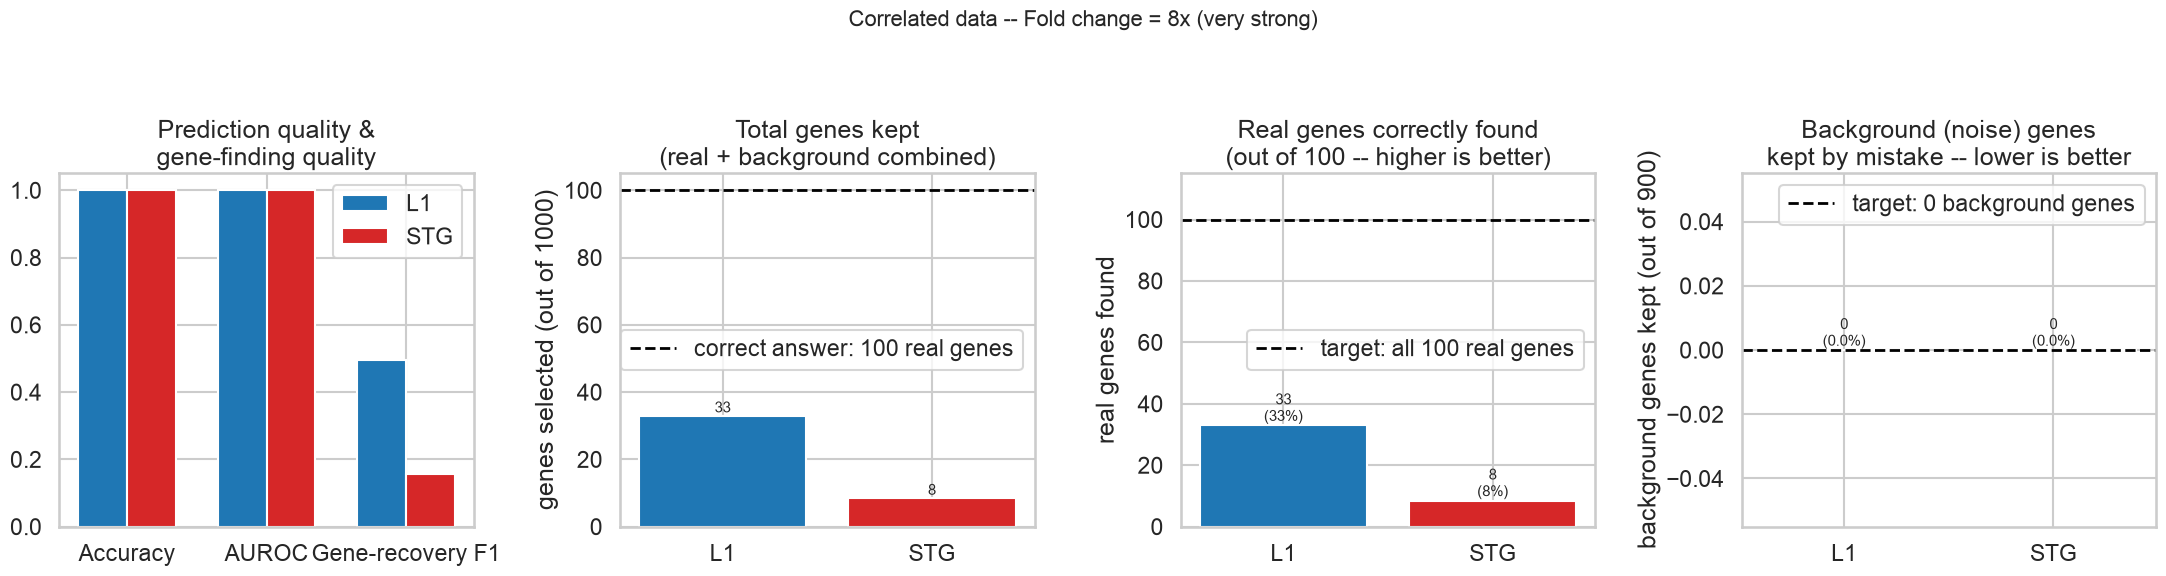

In [28]:
experiment2_correlated_results["8"] = run_condition("correlated", LAMBDA_FIXED, **{"fold_change": 8})
plot_data_overview(experiment2_correlated_results["8"], "Correlated data -- Fold change = 8x (very strong)")
plot_method_comparison(experiment2_correlated_results["8"], "Correlated data -- Fold change = 8x (very strong)")

#### Experiment 2, Part 2 (Correlated data), Setting E: Fold change = 10x (extreme)

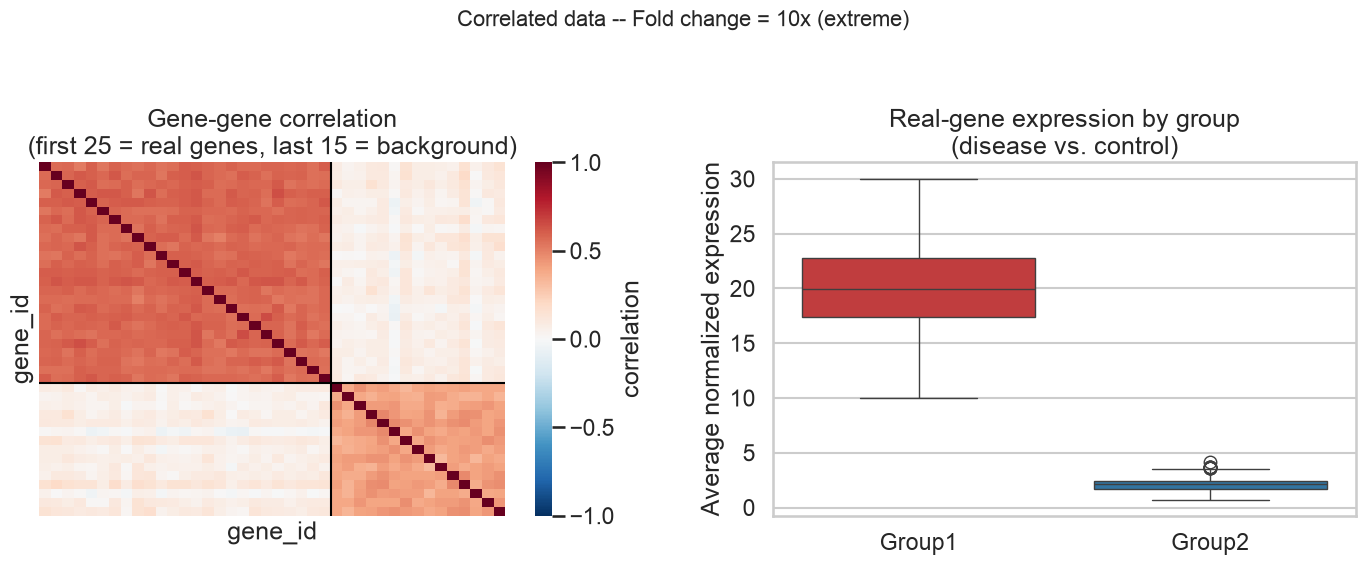

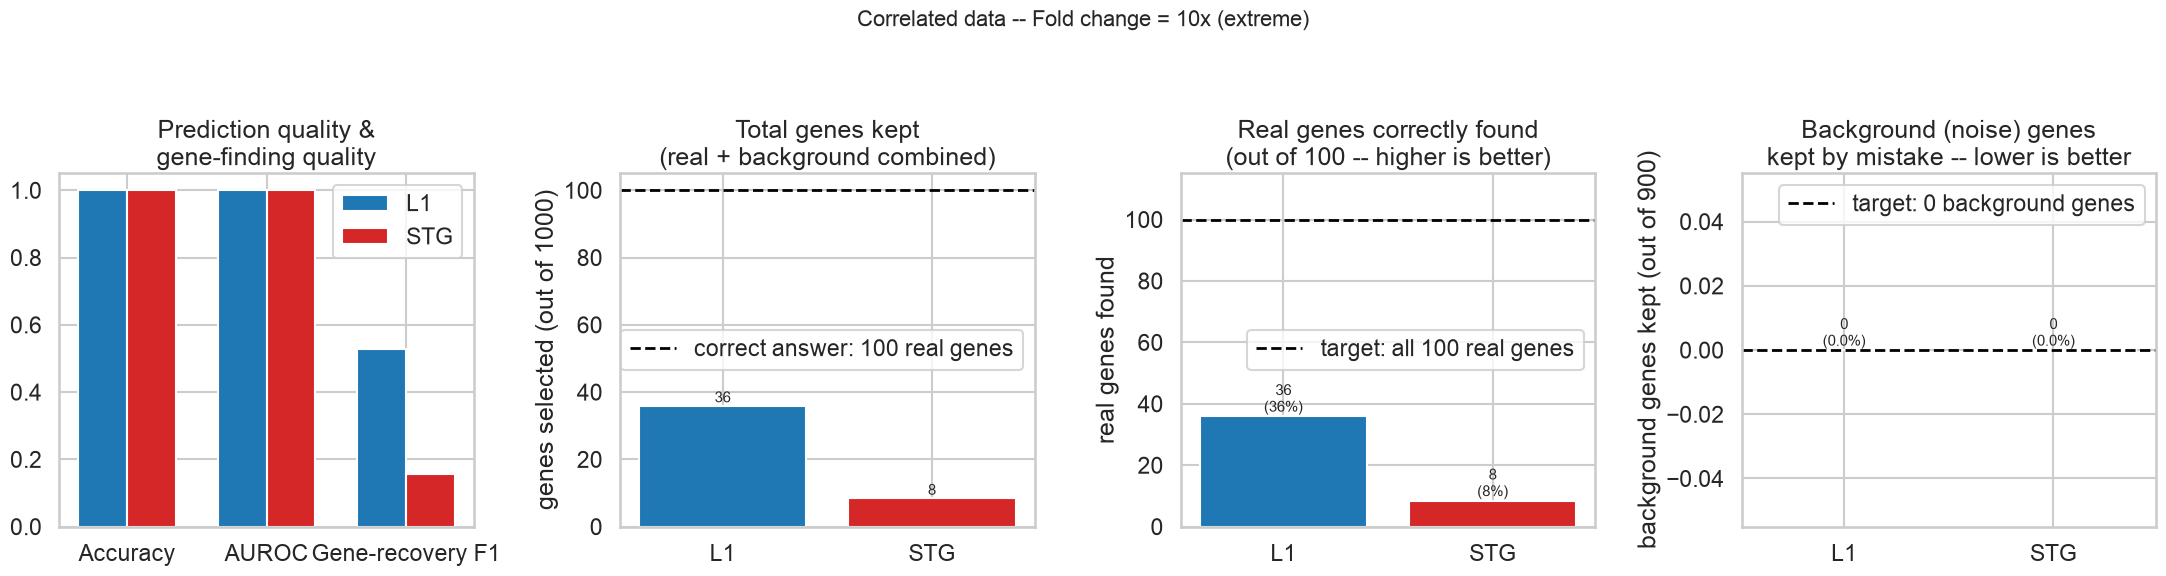

In [29]:
experiment2_correlated_results["10"] = run_condition("correlated", LAMBDA_FIXED, **{"fold_change": 10})
plot_data_overview(experiment2_correlated_results["10"], "Correlated data -- Fold change = 10x (extreme)")
plot_method_comparison(experiment2_correlated_results["10"], "Correlated data -- Fold change = 10x (extreme)")

### Experiment 2 summary — flat vs. correlated, side by side

One combined table with both parts, plus a bonus trend picture comparing all four
lines together (L1 and STG, each shown for both flat and correlated data) — solid
lines are correlated data, dashed lines are flat data.

In [30]:
exp2_rows = []
x_labels_exp2 = {"2": 2, "4": 4, "6": 6, "8": 8, "10": 10}
for data_type, results_dict in [("flat", experiment2_flat_results), ("correlated", experiment2_correlated_results)]:
    for key, x_val in x_labels_exp2.items():
        for method in ("L1", "STG"):
            a = results_dict[key]["averaged"][method]
            exp2_rows.append({"data_type": data_type, "fold_change": x_val, "setting": key, "method": method, **a})

exp2_summary_df = pd.DataFrame(exp2_rows)
pd.set_option("display.max_columns", None)
exp2_summary_df.round(3)

,data_type,fold_change,setting,method,accuracy,auroc,n_selected,precision,recall,f1,n_signal_recovered,n_background_leaked,pct_signal_recovered,pct_background_leaked
0,flat,2,2,L1,1.000,1.000,688.5,0.145,1.000,0.254,100.0,588.5,100.0,65.389
1,flat,2,2,STG,1.000,1.000,7.5,1.000,0.075,0.139,7.5,0.0,7.5,0.000
2,flat,4,4,L1,1.000,1.000,50.5,1.000,0.505,0.670,50.5,0.0,50.5,0.000
3,flat,4,4,STG,1.000,1.000,8.0,1.000,0.080,0.148,8.0,0.0,8.0,0.000
4,flat,6,6,L1,1.000,1.000,57.0,1.000,0.570,0.726,57.0,0.0,57.0,0.000
5,flat,6,6,STG,1.000,1.000,8.0,1.000,0.080,0.148,8.0,0.0,8.0,0.000
6,flat,8,8,L1,1.000,1.000,58.0,1.000,0.580,0.734,58.0,0.0,58.0,0.000
7,flat,8,8,STG,1.000,1.000,8.5,1.000,0.085,0.156,8.5,0.0,8.5,0.000
8,flat,10,10,L1,1.000,1.000,63.0,1.000,0.630,0.773,63.0,0.0,63.0,0.000
9,flat,10,10,STG,1.000,1.000,8.5,1.000,0.085,0.156,8.5,0.0,8.5,0.000


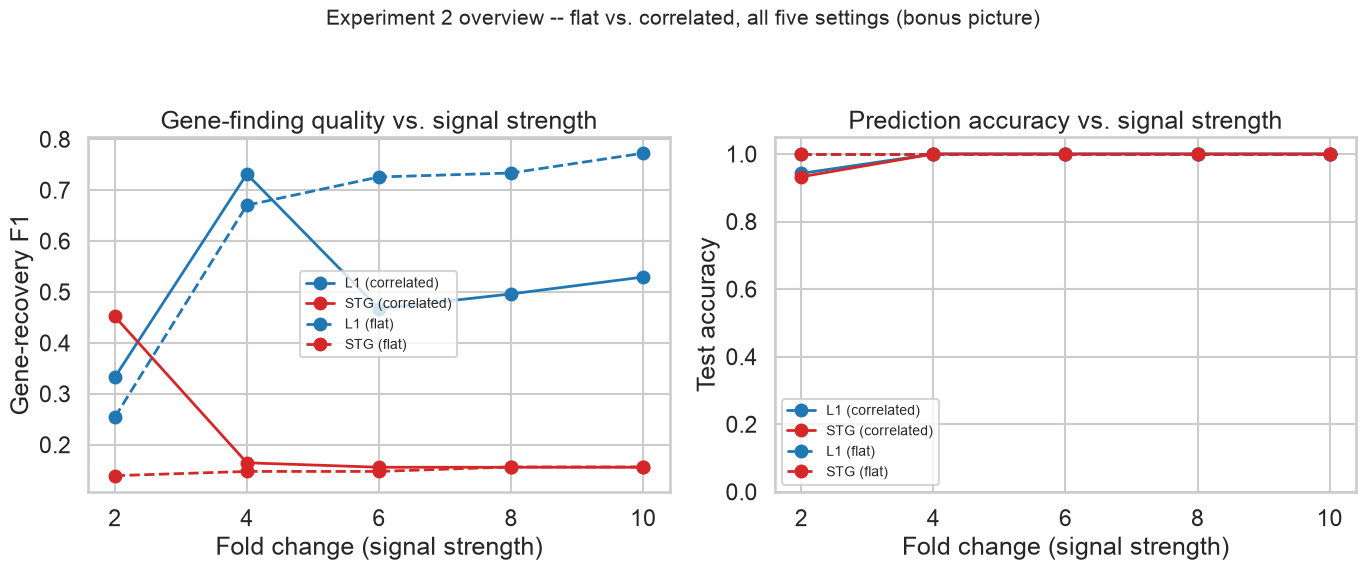

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for data_type, linestyle in [("correlated", "-"), ("flat", "--")]:
    for method in ("L1", "STG"):
        sub = exp2_summary_df[
            (exp2_summary_df["method"] == method) & (exp2_summary_df["data_type"] == data_type)
        ].sort_values("fold_change")
        label = f"{method} ({data_type})"
        axes[0].plot(sub["fold_change"], sub["f1"], marker="o", linewidth=2, linestyle=linestyle,
                     label=label, color=METHOD_COLORS[method])
        axes[1].plot(sub["fold_change"], sub["accuracy"], marker="o", linewidth=2, linestyle=linestyle,
                     label=label, color=METHOD_COLORS[method])

axes[0].set_xlabel("Fold change (signal strength)")
axes[0].set_ylabel("Gene-recovery F1")
axes[0].set_title("Gene-finding quality vs. signal strength")
axes[0].legend(fontsize=10)

axes[1].set_xlabel("Fold change (signal strength)")
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Prediction accuracy vs. signal strength")
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.05)

fig.suptitle("Experiment 2 overview -- flat vs. correlated, all five settings (bonus picture)", y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

## Next up

Experiments 3–4 (measurement noise, patient-to-patient variability) follow the
same flat-vs-correlated two-part pattern as Experiment 2 above, and will be added
once this section is confirmed to look right.